# Benchmarking OSM parsing tools

:::{admonition} TL;DR
:class: tip

*Benchmarks show that as of June 2026 `pyrosm` is the fastest and most memory efficient OSM data parser designed for Python that can extract data efficiently from large PBF files to GeoDataFrames (up to multiple Gigabytes with 24 GiB of RAM). Pyrosm is also able to efficiently crop and modify large `.osm.pbf` files and save them to disk in PBF format - although it is not the fastest tool around (where C++ based osmium-tool dominates).*
:::

`Pyrosm` aims to be an easy-to-use and fast Python tool for parsing OpenStreetMap data from Protocolbuffer Binary Format (PBF) files into [geopandas](http://geopandas.org/) which is the Python's go-to library for working with spatial data. Pyrosm has been written mainly in Cython (Python with C-like performance) using vectorized and parallelized operations whenever possible which makes it very efficient for parsing OpenStreetMap data. Pyrosm deserializes the protocol buffer messages using Google’s Protobuf library with its fast C `upb` backend. Google’s Protocol Buffers is a commonly used and efficient method to serialize and compress structured data which is also used by OpenStreetMap contributors to distribute the OSM data in PBF format (Protocolbuffer Binary Format).

To better understand the performance of Pyrosm, here it is compared against other similar tools. There are various tools available for parsing OSM data, such as [OSMnx](https://github.com/gboeing/osmnx), [Osmosis](https://github.com/openstreetmap/osmosis/), [pyosmium/libosmium](https://github.com/osmcode/pyosmium), [QuackOSM](https://github.com/kraina-ai/quackosm) and [osmextract (R)](https://github.com/ropensci/osmextract/). The most similar tool to Pyrosm (in terms of functionality) is OSMnx which makes it possible to retrieve OpenStreetMap data easily into GeoDataFrames utilizing OverPass API. 

Here, we compare [**pyrosm**](https://pyrosm.readthedocs.io/) against six other
widely used OpenStreetMap tools on a set of **identical, verifiable tasks**:

| Tool | What it is | Reads a local `.osm.pbf`? |
| --- | --- | --- |
| [**pyrosm**](https://pyrosm.readthedocs.io/) | Cython OSM→GeoPandas reader (in-memory + out-of-core engines) | yes |
| [**osmnx**](https://osmnx.readthedocs.io/) | OSM→GeoPandas/NetworkX via the Overpass API | no (downloads from Overpass) |
| [**QuackOSM**](https://github.com/kraina-ai/quackosm) | DuckDB-based OSM→GeoParquet/GeoPandas reader | yes |
| [**pyosmium**](https://osmcode.org/pyosmium/) | Python bindings to libosmium (streaming C++ reader/writer) | yes |
| [**osmium-tool**](https://osmcode.org/osmium-tool/) | C++ command-line tool (libosmium); filter + export to GeoJSON, read with GeoPandas | yes |
| [**Osmosis**](https://wiki.openstreetmap.org/wiki/Osmosis) | Java command-line tool for manipulating PBF data | yes |
| [**osmextract**](https://github.com/ropensci/osmextract) | R package: downloads and reads OSM via GDAL into `sf` | yes |

We benchmark three tasks:

1. **Parse buildings** into a GeoDataFrame across a ladder of areas (a single neighbourhood up to a whole country), measuring both **time and peak memory** and comparing pyrosm's in-memory and out-of-core engines.
2. **Parse the road network** (`highway=*` ways) similarly into a GeoDataFrame across a ladder of areas (as with buildings), measuring both **time and peak memory** and comparing pyrosm's in-memory and out-of-core engines.
3. **Crop a large PBF** (all of Finland) down to the Helsinki region and **write the result back to disk** as a new `.osm.pbf`.

### How the comparison is kept fair

- **Same input.** For the parsing tasks every local-file tool reads the *same* PBF; OSMnx
  queries the Overpass API for the *same* geographic extent (the bounding box of that PBF).
- **Same selection.** Each tool is given the same OSM tag filter (`building` / `highway`).
- **Same output, compared by geometry type.** OSM tools disagree on whether a tag filter
  should also return tagged *nodes* (e.g. `highway=bus_stop`) or *areas*. To compare "apples with
  apples" as best as possible, we normalise every result to the geometry that defines the task — **polygons** for
  buildings, **lines** for roads — and report those counts side by side so you can confirm the
  tools really did the same work. In terms of parsed tags, we aim to keep the workload comparable,
  i.e. also OSM tags are parsed alongside with the geometries. 
- **Isolated runs, time and memory.** Each parse runs in its **own subprocess** (the [`bench_worker.py`](bench_worker.py) script), and
  the notebook samples the whole process tree's **peak memory** (psutil) as well as wall-clock
  time, with a per-size timeout; an out-of-memory kill or timeout is recorded rather than crashing
  the run. The ladder repeats parsing data from different areas multiple times and records a median time and peak memory of those runs as a result. QuackOSM is called with `ignore_cache=True` and pyrosm's out-of-core cache is cleared before each read, so we
  measure parsing, not a cache hit.
- **Verified cropping.** Each cropped PBF is read back and its building count compared, so a
  "fast" crop that dropped data is caught.

> **Not every tool can do every task.** OSMnx works from the Overpass API and does not read or
crop local PBF files, so it does not take part in the cropping task. Osmosis manipulates PBF
data and does not build GeoDataFrames, so it does not take part in the parsing tasks. osmextract
(an R package) reads OSM layers through GDAL into `sf`/GeoPackage rather than writing a cropped
`.osm.pbf`, so it joins the parsing tasks but not the cropping task. Being an R tool, its parsing results
are produced by the companion [`osmextract_benchmark_scaling.ipynb`](osmextract_benchmark_scaling.ipynb) (run with an R kernel via the [`bench_worker.R`](bench_worker.R) subprocess worker). **pydriosm** also reads local `.osm.pbf` files (through GDAL), but it has no read-time tag filter — `PBFReadParse.read_pbf` returns whole layers that you filter in pandas afterwards — so it cannot do a like-for-like `building`/`highway` extraction and is left out of these parsing benchmarks. **osmium-tool** (the libosmium command-line program) parses by exporting to GeoJSON and reading it with GeoPandas, so it joins the parsing tasks, and crops with `osmium extract` for the cropping task. 


> **Cores differ by tool.** These parsing runs use each tool's natural defaults rather than pinning cores, so the time chart mixes single- and multi-core readers: pyrosm's in-memory engine and pyosmium are single-threaded, while QuackOSM (DuckDB threads = all cores), osmium-tool (OSMIUM_POOL_THREADS) and pyrosm's out-of-core engine with `workers="auto"` use multiple cores for larger files and a single-core for files under ~70 MB (i.e. Kamppi and Helsinki run on one core). Peak memory is unaffected by core count — read the time chart with this in mind.


### Hardware

The benchmarks are conducted with MacBook Air M5 laptop with 24GB of RAM, 10 cores and SSD-disk running on MacOS Tahoe 26.5. 

### Data 

- **Buildings** are parsed across a ladder of areas of increasing size:
   - **Kamppi** neighbourhood (clipped from the Helsinki extract),
   - **Helsinki Region** (~63 MB, BBBike),
   - **New York City** (~150 MB, BBBike),
   - **Paris** (~238 MB, BBBike),
   - **Finland** (~726 MB, Geofabrik), and
   - **Spain** (~1456 MB, Geofabrik).
   - **South America** (~4027 MB, Geofabrik) --> Only tested with pyrosm + quackosm
   
The in-memory engine and OSMnx are limited to the smaller areas they can handle (OSMnx serves the Overpass-friendly smaller extents; the in-memory reader is skipped on Spain due to certain out-of-memory error). **Cropping** uses **all of Finland** (approx. 700 MB from Geofabrik) as the large input that gets cropped down to the Helsinki region.


### Results

Here, we introduce the key benchmarking results so that you don't need to read the whole document. Read further to see the exact results and calculations. The results represent median wall-clock times from a single machine, testing a few datasets in different sizes. Thus, the rankings are indicative rather than exact and should be read with caution. Systematic benchmarking under identical conditions is hard: memory usage, thermal throttling, and background OS processes can all influence timings. However, we made every effort to not interfere with the benchmarking processes in any way while they were running (i.e. nothing else was done on the computer during the runs).

**The counts confirm the tools mostly did the same work (read further to see the exact results).** Building-polygon and road-line counts agree across the local-file tools to within roughly a percent (≈176,000 buildings and ≈297,000 road lines), which is the evidence that each tool parsed the same features. OSMnx is the exception: it returns a directed routing graph from live Overpass data, so its road count (≈1.06 million edges) is not comparable/fair to the raw way counts of the other tools, which is good to keep in mind. However, we found that this was the fastest way to retrieve the network data with osmnx which is the reason why we relied on this approach. 

#### Parsing buildings — time and memory as the area grows

The two charts below plot parse **time** and **peak memory** against area size, from the Kamppi neighbourhood up to all of Spain, each parse run in an isolated subprocess. Overall, pyrosm's new out-of-core backend reader is very performant when reading buildings from OSM.PBF. Together with osmextract (R tool), they represent the fastest parsers in these tests (very close in terms of performance). osmextract (R/GDAL) is timed and memory-profiled on the same files in the companion R notebook. QuackOSM (DuckDB) and pyosmium (streaming) also stay within memory but tend to be slower. 

When comparing pyrosm's two backends, the **in-memory** engine is quick on the smallest inputs, but its peak memory climbs with size fast. The **out-of-core** engine (`workers="auto"`) keeps peak memory bounded — on the larger areas roughly half the in-memory peak — and parses Finland and Spain end to end. 

![Buildings speed](figures/buildings_time.png)

![Buildings peak memory](figures/buildings_memory.png)

#### Parsing the road network — time and memory as the area grows

The same comparison as buildings, for `highway=*` lines. pyrosm's out-of-core engine again keeps peak memory bounded where the in-memory engine climbs (and is skipped on Spain). Here, the osmextract dominates and is both fastest and most memory efficient parser out of all the tools by a clear margin. pyrosm's out-of-core engine is the second fastest and memory-efficient tool overall, and most performant one of the Python tools.

osmium-tool's time is dominated by the GeoJSON export-and-read round-trip rather than the parse, and OSMnx returns a simplified routing graph (higher, non-comparable line count) shown only on the small areas. osmextract (R/GDAL) is the notable performer here — on the network it is faster than pyrosm's out-of-core engine across the ladder and keeps a low memory footprint.

![Road network speed](figures/network_time.png)

![Road network peak memory](figures/network_memory.png)

#### pyrosm vs QuackOSM on a matched workload

The charts above let each tool follow its own defaults, which do not always do exactly the same tag work — QuackOSM appears twice (with and without tag columns), neither of which lines up exactly against pyrosm. The figure below removes that ambiguity: pyrosm (out-of-core) and QuackOSM both read **only the geometry plus the `building` key** — no extra tag columns — across the whole ladder up to South America. On this like-for-like workload pyrosm is faster at every size (e.g. Finland ≈28 s vs ≈42 s, Spain ≈54 s vs ≈77 s, South America ≈221 s vs ≈313 s) and has the lower peak memory at every size except the largest, where the two are essentially tied (South America ≈18.3 GB vs ≈18.1 GB). Both the speed and the memory gap are widest on the small and mid-size areas and narrow as the files grow.

![pyrosm vs QuackOSM, matched workload](figures/head_to_head.png)

#### Cropping a country down to a region

In terms of the third task, focusing on the PBF cropping, osmium-tool is the clear leader, at ≈15 s on a single core and ≈3 s across ten threads, which makes sense as the bounding-box extract is exactly what its C++ engine is built for. pyrosm crops in ≈99 s on one worker and ≈25 s with ten, or ≈64 s in its compact mode that matches osmium-tool's smaller output file size. Thus, parallelization provides a significant boost to pyrosm cropping capabilities in a similar manner as osmium-tool. Osmosis sits in the middle (≈168 s), and pyosmium is the slowest and does not benefit from more threads (≈226 s to ≈228 s), because its extract loop runs in single-threaded Python.

![Cropping benchmarks](figures/crop_times.png)


#### Where pyrosm fits

pyrosm is not the single fastest tool at every task: osmextract (R/GDAL) is faster on the road network and very memory-lean, and osmium-tool dominates cropping. On building extraction, though, pyrosm's out-of-core engine is now at or near the front across the ladder while keeping memory bounded. It is the fastest OSM parser designed for Python, and across the whole set it stays consistently among the quickest. Its main strength is the combination of versatility and ease of use. One `OSM` object reads buildings, roads, POIs, etc; the same object exports networks to igraph, NetworkX, or Pandarm and crops to a new PBF. Most of these require only a single line of code (e.g. `OSM(fp).get_buildings()`) returning a fully attributed GeoDataFrame, where pyosmium needs a hand-written WKB loop and osmium-tool needs a two-step shell pipeline plus a file read. 

## Running the tests

The rest of this Notebook/page documents how the benchmarks were calculated exactly. With these tests, we have tried to be as fair as possible. However, as we are not the experts of all these tools, there might be ways to make the tools more performant than what they show here. Thus, we would be very happy to hear if any of the benchmarks require improvements to make the comparison between tools fairer. To do this, [open an issue in Github](https://github.com/pyrosm/pyrosm/issues/new/choose).

### Installation

All seven tools (plus the notebook's plotting/dataframe deps) can be installed into one
environment. pyrosm, osmnx, QuackOSM and pyosmium are Python packages; Osmosis is a Java tool;
osmextract is an R package.

```bash
# Python tools (conda-forge recommended for the geo-stack)
# ipywidgets is needed so QuackOSM/DuckDB can manage their progress bar inside Jupyter.
mamba install -c conda-forge pyrosm osmnx quackosm pyosmium osmium-tool geopandas matplotlib pandas ipywidgets

# Osmosis (Java command-line tool) + a Java runtime
mamba install -c conda-forge openjdk
# then download Osmosis from https://github.com/openstreetmap/osmosis/releases
# and make sure the `osmosis` launcher is on your PATH.

# osmextract is an R package (run via the companion osmextract_benchmark_scaling.ipynb).
# Install R + sf (GDAL) + the Jupyter R kernel from conda-forge, then osmextract from CRAN:
mamba install -c conda-forge r-base r-sf r-irkernel
R -e 'install.packages("osmextract", repos="https://cloud.r-project.org")'
R -e 'IRkernel::installspec()'   # registers the "R" Jupyter kernel
```

If a tool is missing, its cells below are skipped automatically (they are guarded by an
availability check), so the rest of the notebook still runs end to end.


### Setup: imports, tool detection and helpers

Many code cells are hidden from the website to make the report easier to read, but you can open the code cells if you're interested to see how the benchmarks are run.

In [1]:
import os
import time
import shutil
import statistics
import subprocess
import tempfile
import warnings
from collections import namedtuple
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")  # keep the benchmark output readable

# Median window for the single-area road task. The buildings task sets its own per-area
# repeats via the AREAS ladder below (small areas 10x; the big country files 3x).
REPEATS = 3
# Cropping reads/writes a multi-hundred-MB file; once is enough.
CROP_REPEATS = 1

In [2]:
# Import the Python tools and record which ones are installed.
# (Osmosis is a separate command-line program, so we look for it on PATH.)
import pyrosm
from pyrosm import OSM, get_data
import osmnx as ox
import quackosm as qosm
import osmium
from importlib.metadata import version

import re
import subprocess


def osmosis_version(osmosis_bin="osmosis"):
    """Return the Osmosis version (e.g. '0.49.2'), or None if it can't be determined.

    Osmosis has no plain --version flag, but it logs 'Osmosis Version X.Y.Z' to stderr
    at startup, so we run a harmless command (--help) and parse that line.
    """
    try:
        result = subprocess.run(
            [osmosis_bin, "--help"], capture_output=True, text=True, timeout=30,
        )
    except (OSError, subprocess.SubprocessError):
        return None
    match = re.search(r"Osmosis Version (\S+)", result.stdout + result.stderr)
    return match.group(1) if match else None


def osmium_tool_version(osmium_bin="osmium"):
    """Return the osmium-tool version (e.g. '1.19.0'), or None if it can't be determined.

    The osmium command-line tool (separate from the pyosmium bindings) prints
    'osmium version X.Y.Z' on `osmium --version`, so we run it and parse that line.
    """
    try:
        result = subprocess.run(
            [osmium_bin, "--version"], capture_output=True, text=True, timeout=30,
        )
    except (OSError, subprocess.SubprocessError):
        return None
    match = re.search(r"osmium version (\S+)", result.stdout + result.stderr)
    return match.group(1) if match else None


# Command-line tools (found on PATH).
OSMOSIS_BIN = shutil.which("osmosis")
OSMIUM_BIN = shutil.which("osmium")

available_tools = {
    "pyrosm": pyrosm.__version__,
    "osmnx": ox.__version__,
    "quackosm": qosm.__version__,
    "pyosmium": version("osmium"),
    "osmosis": osmosis_version(OSMOSIS_BIN) if OSMOSIS_BIN else None,
    "osmium-tool": osmium_tool_version(OSMIUM_BIN) if OSMIUM_BIN else None,
}


def is_installed(tool):
    """True if `tool` was detected above (used to skip tools that aren't installed)."""
    return bool(available_tools.get(tool))


print("Detected tools:")
for tool, info in available_tools.items():
    print(f"  {tool:9} {info or 'NOT available'}")

Detected tools:
  pyrosm    0.10.0rc1
  osmnx     2.1.0
  quackosm  0.18.0
  pyosmium  4.3.1
  osmosis   0.49.2
  osmium-tool 1.19.0


In [3]:
# Each benchmark run appends one row (a dict) to this list which is turned into a table later
parsing_results = []

# A tag filter can return several geometry types (a `highway` filter, for instance, also
# returns bus-stop *points*). To compare tools fairly we count only the geometry that
# defines the task: polygons for buildings, lines for roads
POLYGON_TYPES = {"Polygon", "MultiPolygon"}
LINE_TYPES = {"LineString", "MultiLineString"}


def count_polygons(geodataframe):
    """Number of polygon rows in the GeoDataFrame."""
    return int(geodataframe.geometry.geom_type.isin(POLYGON_TYPES).sum())


def count_lines(geodataframe):
    """Number of line rows in the GeoDataFrame."""
    return int(geodataframe.geometry.geom_type.isin(LINE_TYPES).sum())


def median_runtime(function, repeats, *args):
    """Call function(*args) `repeats` times; return median seconds and the last result of the run."""
    runtimes = []
    result = None
    for i in range(repeats):
        started = time.perf_counter()
        result = function(*args)
        runtimes.append(time.perf_counter() - started)
    return statistics.median(runtimes), result


def bounding_box_of(geodataframe):
    """Extent of a GeoDataFrame as a shapely box (used to give osmnx the same area)."""
    from shapely.geometry import box
    if geodataframe is None or geodataframe.empty:
        return None
    return box(*geodataframe.total_bounds)


def run_parsing_task(task, tool, parse, count_features, repeats=REPEATS,
                     area=None, pbf=None, requires=None):
    """Benchmark one tool on one parsing task and store the result.

    `parse` is called as parse(pbf) when a `pbf` is given (the buildings ladder hands each
    tool the current area's file) and as parse() otherwise (the single-area road task).
    `count_features` is count_polygons or count_lines, `area` is recorded so timings can be
    compared across input sizes, and `requires` names the package to check when `tool` is a
    display label such as "pyrosm (in-memory)". Tools that aren't installed are skipped and
    errors are recorded instead of raised. Returns the parsed GeoDataFrame.
    """
    if not is_installed(requires or tool):
        print(f"  {tool:22} not installed - skipped")
        return None

    parse_args = (pbf,) if pbf is not None else ()
    try:
        seconds, geodataframe = median_runtime(parse, repeats, *parse_args)
    except Exception as error:
        parsing_results.append({
            "task": task, "area": area, "tool": tool, "seconds": None,
            "features": None, "status": f"{type(error).__name__}: {error}",
        })
        print(f"  {tool:22} FAILED - {error}")
        return None

    features = count_features(geodataframe)
    parsing_results.append({
        "task": task, "area": area, "tool": tool, "seconds": round(seconds, 2),
        "features": features, "status": "ok",
    })
    print(f"  {tool:22} {seconds:7.2f} s   {features:>8,} features")
    return geodataframe


RESULTS_CSV = "osm_parsing_results.csv"
RESULT_COLUMNS = ["task", "area", "tool", "seconds", "peak_mb", "features", "status"]


def record_result(row):
    """Upsert one result row into parsing_results and RESULTS_CSV, keyed by (task, area, tool),
    and write the CSV immediately -- so results are exported as each tool finishes, and re-running
    a tool updates its row instead of appending a duplicate."""
    key = (row["task"], row["area"], row["tool"])
    parsing_results[:] = [r for r in parsing_results
                          if (r["task"], r["area"], r["tool"]) != key]
    parsing_results.append(row)
    table = pd.read_csv(RESULTS_CSV) if os.path.exists(RESULTS_CSV) \
        else pd.DataFrame(columns=RESULT_COLUMNS)
    table = table[~((table["task"] == row["task"]) & (table["area"] == row["area"])
                    & (table["tool"] == row["tool"]))]
    table = pd.concat([table, pd.DataFrame([row], columns=RESULT_COLUMNS)], ignore_index=True)
    table.to_csv(RESULTS_CSV, index=False)

In [4]:
# Each parse runs in its own subprocess (bench_worker.py) so it is isolated: we sample
# the whole process tree's peak memory with psutil and enforce a per-size timeout, and a crash or
# out-of-memory kill is recorded rather than taking the kernel down. 
# Inspired by the osm-python-readers-benchmark (https://github.com/RaczeQ/osm-python-readers-benchmark)
import sys
import json
import psutil

BENCH_WORKER = str(Path("bench_worker.py").resolve())
assert Path(BENCH_WORKER).exists(), f"bench_worker.py must sit next to this notebook ({BENCH_WORKER})"


def monitor_parse(worker_tool, pbf, timeout, extra_args=None):
    """Run one tool on one PBF in an isolated subprocess; return its time, the process tree's
    peak RSS (MB), the feature count and a status. `extra_args` are appended to the worker
    command (osmnx uses them to pass the bounding box it queries). A timeout kills the tree; a
    crash / OOM-kill is reported as a non-ok status with the peak memory reached before it died."""
    command = [sys.executable, BENCH_WORKER, worker_tool, str(pbf)]
    if extra_args:
        command += [str(arg) for arg in extra_args]
    proc = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.DEVNULL, text=True)
    tree = psutil.Process(proc.pid)
    peak = 0
    started = time.time()
    while proc.poll() is None:
        if time.time() - started > timeout:
            for child in tree.children(recursive=True):
                try:
                    child.kill()
                except psutil.Error:
                    pass
            proc.kill()
            return {"status": "timeout", "seconds": None,
                    "peak_mb": round(peak / 1e6, 1), "features": None}
        try:
            rss = tree.memory_info().rss + sum(
                c.memory_info().rss for c in tree.children(recursive=True))
            peak = max(peak, rss)
        except psutil.Error:
            pass
        time.sleep(0.05)
    out = proc.stdout.read().strip()
    if proc.returncode == 0 and out:
        parsed = json.loads(out.splitlines()[-1])
        return {"status": "ok", "seconds": round(parsed["seconds"], 2),
                "peak_mb": round(peak / 1e6, 1), "features": parsed["features"]}
    return {"status": f"OOM/crash (exit {proc.returncode})", "seconds": None,
            "peak_mb": round(peak / 1e6, 1), "features": None}

In [5]:
# pyosmium streams OSM elements but has no GeoDataFrame API, so these helpers build the
# geometry (with libosmium's WKB factory) AND collect every tag, producing a full
# attribute table comparable to what pyrosm / QuackOSM / osmnx return.


def read_polygons_with_pyosmium(pbf_path, key, location_storage="flex_mem"):
    """Read every area (closed way or multipolygon) carrying `key` -> polygons + tags."""
    from shapely import from_wkb

    wkb_factory = osmium.geom.WKBFactory()
    rows = []

    fp = (osmium.FileProcessor(pbf_path)
          .with_locations(location_storage)
          .with_areas(osmium.filter.KeyFilter(key))   # pass 1: only assemble key-tagged relations
          .with_filter(osmium.filter.KeyFilter(key)))  # output: only yield key-tagged objects

    for element in fp:
        if not element.is_area():
            continue
        try:
            wkb = wkb_factory.create_multipolygon(element)
        except Exception:
            continue
        if wkb:
            row = {tag.k: tag.v for tag in element.tags}
            row["geometry"] = from_wkb(bytes.fromhex(wkb))
            rows.append(row)

    if not rows:
        return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
    return gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")


def read_lines_with_pyosmium(pbf_path, key, location_storage="flex_mem"):
    """Read every way carrying `key` -> linestrings + tags."""
    from shapely import from_wkb

    wkb_factory = osmium.geom.WKBFactory()
    rows = []

    fp = (osmium.FileProcessor(pbf_path, osmium.osm.NODE | osmium.osm.WAY)
          .with_locations(location_storage)
          .with_filter(osmium.filter.KeyFilter(key)))

    for element in fp:
        if not (element.is_way() and len(element.nodes) >= 2):
            continue
        try:
            wkb = wkb_factory.create_linestring(element)
        except Exception:
            continue
        if wkb:
            row = {tag.k: tag.v for tag in element.tags}
            row["geometry"] = from_wkb(bytes.fromhex(wkb))
            rows.append(row)

    if not rows:
        return gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
    return gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")


def crop_with_pyosmium(input_pbf, output_pbf, bbox):
    """Crop `input_pbf` to a bounding box (keeping complete ways) and write `output_pbf`.

    Three passes over the file:
      1. find the ids of nodes inside the box,
      2. find ways that touch the box, keeping ALL of their nodes so border-crossing ways
         stay whole,
      3. write the kept nodes, ways and relations.
    """
    if os.path.exists(output_pbf):
        os.remove(output_pbf)
    west, south, east, north = bbox

    nodes_in_box = set()
    for node in (osmium.FileProcessor(input_pbf)
                 .with_filter(osmium.filter.EntityFilter(osmium.osm.NODE))):
        if west <= node.location.lon <= east and south <= node.location.lat <= north:
            nodes_in_box.add(node.id)

    ways_to_keep = set()
    nodes_to_keep = set(nodes_in_box)
    for way in (osmium.FileProcessor(input_pbf)
                .with_filter(osmium.filter.EntityFilter(osmium.osm.WAY))):
        way_node_ids = [node.ref for node in way.nodes]
        if any(node_id in nodes_in_box for node_id in way_node_ids):
            ways_to_keep.add(way.id)
            nodes_to_keep.update(way_node_ids)

    writer = osmium.SimpleWriter(output_pbf)
    try:
        for element in osmium.FileProcessor(input_pbf):
            if element.is_node() and element.id in nodes_to_keep:
                writer.add_node(element)
            elif element.is_way() and element.id in ways_to_keep:
                writer.add_way(element)
            elif element.is_relation() and any(
                (member.type == "w" and member.ref in ways_to_keep)
                or (member.type == "n" and member.ref in nodes_to_keep)
                for member in element.members
            ):
                writer.add_relation(element)
    finally:
        writer.close()
    return output_pbf


def crop_with_osmosis(input_pbf, output_pbf, bbox, osmosis_bin):
    """Crop to a bounding box (complete ways) by calling the Osmosis command-line tool."""
    if os.path.exists(output_pbf):
        os.remove(output_pbf)
    west, south, east, north = bbox
    subprocess.run(
        [osmosis_bin,
         "--read-pbf", str(input_pbf),
         "--bounding-box", f"left={west}", f"bottom={south}",
         f"right={east}", f"top={north}", "completeWays=yes",
         "--write-pbf", str(output_pbf)],
        check=True,
    )
    return output_pbf


# osmium-tool is the C++ command-line program (separate from the pyosmium bindings). It has
# no GeoDataFrame API either, so we filter + export to GeoJSON Text Sequence on disk and read
# that back with geopandas.

def parse_with_osmium_tool(pbf_path, key, geometry_type, osmium_bin="osmium"):
    """Parse features tagged `key` into a GeoDataFrame using the osmium command-line tool.

    Two commands plus a read:
      1. osmium tags-filter -> keep objects carrying `key` (and the nodes/members they
         reference, so geometries can be built),
      2. osmium export -> write GeoJSON Text Sequence, keeping only `geometry_type`
         ("polygon" or "linestring"); this replaces the manual geometry-type split the
         pyosmium helpers do,
      3. geopandas reads the .geojsonseq.

    Notice: This is not the way osmium is typically used as the core focus of the library is not to export
    the data to GIS file formats or GeoDataFrame. Thus, this functionality represents a workaround which is not
    optimized at all in terms of performance. 
    """
    work_dir = tempfile.gettempdir()
    filtered_pbf = os.path.join(work_dir, f"osmium_{key}.osm.pbf")
    geojson_seq = os.path.join(work_dir, f"osmium_{key}.geojsonseq")

    subprocess.run(
        [osmium_bin, "tags-filter", "--overwrite", pbf_path, f"w/{key}", "-o", filtered_pbf],
        check=True, capture_output=True,
    )
    subprocess.run(
        [osmium_bin, "export", "--overwrite", filtered_pbf,
         "--geometry-types", geometry_type, "-f", "geojsonseq", "-o", geojson_seq],
        check=True, capture_output=True,
    )
    return gpd.read_file(geojson_seq)


def crop_with_osmium_tool(input_pbf, output_pbf, bbox, pool_threads=None, osmium_bin="osmium"):
    """Crop to a bounding box (complete ways) with the osmium command-line tool.

    `pool_threads` sets OSMIUM_POOL_THREADS for the run -- libosmium's PBF (de)compression
    thread pool. None uses libosmium's default (~ CPU count); 1 forces single-threaded.
    """
    west, south, east, north = bbox
    env = dict(os.environ)
    if pool_threads is not None:
        env["OSMIUM_POOL_THREADS"] = str(pool_threads)
    subprocess.run(
        [osmium_bin, "extract", "--overwrite",
         "--strategy", "complete_ways",
         "--bbox", f"{west},{south},{east},{north}",
         input_pbf, "-o", output_pbf],
        env=env, check=True, capture_output=True,
    )
    return output_pbf

### Data

- **Buildings** and **Roads** are parsed across a ladder of areas of increasing size, so the timings show
  how each tool scales with input: **Kamppi** (a neighbourhood clipped out of the Helsinki extract), the **Helsinki Region**, **New York City**, **Paris**, **Finland** and **Spain**. pyrosm is measured with both engines; the in-memory reader and OSMnx run only on the smaller areas they can handle.

- **Cropping** uses **all of Finland** (a few hundred MB from Geofabrik) as the large input
  that gets cropped down to the Helsinki region.

Everything is downloaded automatically by `pyrosm.get_data(...)`. The Finland and Spain
downloads are large and may take a while the first time.

In [6]:
REGION_PBF = get_data("helsinki")  
NEW_YORK_PBF = get_data("New York City")            
PARIS_PBF = get_data("paris")
FINLAND_PBF = get_data("finland")  
SPAIN_PBF = get_data("spain")
SOUTH_AMERICA_PBF = get_data("south_america")

# Helsinki region bounding box (west, south, east, north) for the cropping task.
HELSINKI_BBOX = [24.50, 60.10, 25.25, 60.40]

# QuackOSM writes intermediate GeoParquet to a working directory; keep it out of the repo.
QUACKOSM_WORKDIR = os.path.join(tempfile.gettempdir(), "quackosm_cache")

# Buildings are parsed across a ladder of areas, from a neighbourhood up to a whole country.
# Kamppi is clipped from the Helsinki extract so even the smallest area is a real .osm.pbf that
# every tool reads the same way. `repeats` is the median window (Kamppi/Helsinki 10x, Paris 3x,
# the country files 2x; the slow pyosmium streaming reader is further capped to one rep on the
# big areas in the loop below). `timeout` bounds a single isolated parse, scaled to file size.
KAMPPI_BBOX = [24.920, 60.162, 24.942, 60.172]
KAMPPI_PBF = os.path.join(tempfile.gettempdir(), "kamppi.osm.pbf")
OSM(REGION_PBF, bounding_box=KAMPPI_BBOX).to_pbf(KAMPPI_PBF)

Area = namedtuple("Area", "label pbf repeats timeout")
AREAS = [
    Area("Kamppi",          KAMPPI_PBF,        10,  120),
    Area("Helsinki region", REGION_PBF,        10,  300),
    Area("New York City",   NEW_YORK_PBF,       5,  900),
    Area("Paris",           PARIS_PBF,          3, 1500),
    Area("Finland",         FINLAND_PBF,        3, 3600),
    Area("Spain",           SPAIN_PBF,          3, 3600),
    Area("South America",   SOUTH_AMERICA_PBF,  1, 3600),
]

# Share the exact file paths with the R companion (osmextract_benchmark_scaling.ipynb) so it
# benchmarks osmextract on the very same files.
pd.DataFrame(
    [(a.label, str(Path(a.pbf).resolve()), a.repeats) for a in AREAS],
    columns=["area", "path", "repeats"],
).to_csv("scaling_areas.csv", index=False)

print("Region PBF :", REGION_PBF, f"({os.path.getsize(REGION_PBF)/1e6:.1f} MB)")
print("Finland PBF:", FINLAND_PBF, f"({os.path.getsize(FINLAND_PBF)/1e6:.1f} MB)")
print("\nBuildings area ladder:")
for area in AREAS:
    print(f"  {area.label:16} {area.pbf}  ({os.path.getsize(area.pbf)/1e6:7.1f} MB)")

Region PBF : /private/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/Helsinki.osm.pbf (62.9 MB)
Finland PBF: /private/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/finland-latest.osm.pbf (725.8 MB)

Buildings area ladder:
  Kamppi           /var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/kamppi.osm.pbf  (    6.1 MB)
  Helsinki region  /private/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/Helsinki.osm.pbf  (   62.9 MB)
  New York City    /private/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/newyorkcity.osm.pbf  (  151.6 MB)
  Paris            /private/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/Paris.osm.pbf  (  238.4 MB)
  Finland          /private/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/finland-latest.osm.pbf  (  725.8 MB)
  Spain            /private/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/spain-latest.osm.pbf  ( 1456.1 MB)
  South America    /private/var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/s

### Task 1 — Parse buildings into a GeoDataFrame: time and memory across area sizes

Every tool reads the same `building`-filtered features into a GeoDataFrame, repeated across the area ladder (Kamppi → Spain). Following the practice of the [osm-python-readers-benchmark](https://github.com/RaczeQ/osm-python-readers-benchmark), each parse runs in its **own subprocess** while this notebook samples the whole process tree's **peak memory** (psutil) alongside wall-clock time (with a per-size timeout). Also, a crash or out-of-memory kill is recorded. With pyrosm's **out-of-core** engine (`engine="out_of_core", workers="auto"`), it is possible to parse files that no longer fit in RAM as it streams the data into a temporary cache. The cache is cleared before each read, so it runs the full ladder alongside QuackOSM (DuckDB). The in-memory engine (`engine="in_memory"`) is run up to Finland and skipped on Spain, where it is expected to exceed the 24 GB of RAM. pyosmium (the slow but low-memory streaming reader) and osmium-tool (a GeoJSON-export CLI, not a streaming reader) read the local files too: pyosmium is run on the four smaller areas (Kamppi → Paris) and osmium-tool up to Finland. **OSMnx** is included for the four smaller areas (Kamppi → Paris), but it downloads from the Overpass API rather than reading the local file, so its time and **peak memory reflect cloud work and are not directly comparable** to the local-file readers.

Each area runs in its **own cell** below, so you can run and inspect them one at a time; re-running an area's cell replaces just that area's results.

In [7]:
# Task 1 setup: the buildings readers, and a helper that benchmarks every applicable tool on a
# single area's PBF (isolated subprocess; median time + peak memory). Each area is then run in
# its own cell below. pyrosm is measured with both engines; the in-memory engine is attempted on
# every area so its out-of-memory point on the country files is recorded. osmium-tool (a
# GeoJSON-export CLI) and OSMnx (Overpass API) are shown on the small areas only; the slow
# pyosmium streaming reader runs a single rep on the big areas.
SCALE_READERS = [
    # label,                    worker tool,                     only on these areas (None = all)
    ("pyrosm (in-memory)",      "pyrosm-in-memory",            {"Kamppi", "Helsinki region", "New York City", "Paris", "Finland"}),
    ("pyrosm (out-of-core)",    "pyrosm-out-of-core",          None),
    ("quackosm (with columns)", "quackosm-with-columns",       None),
    ("quackosm (no columns)",   "quackosm-no-columns",         None),
    ("pyosmium",                "pyosmium",                    {"Kamppi", "Helsinki region", "New York City", "Paris"}),
    ("osmium-tool",             "osmium-tool",                 {"Kamppi", "Helsinki region", "New York City", "Paris", "Finland"}),
    ("osmnx",                   "osmnx",                       {"Kamppi", "Helsinki region", "New York City", "Paris"}),
]
SMALL_AREAS = {"Kamppi", "Helsinki region"}
AREA = {area.label: area for area in AREAS}

# OSMnx queries Overpass for a bounding box rather than reading the file; use the same extent as
# the local data (Kamppi's clip box; Helsinki's data extent, read once and cached).
_OSMNX_BBOX = {"Kamppi": KAMPPI_BBOX}


def _osmnx_bbox(area):
    if area.label not in _OSMNX_BBOX:
        _OSMNX_BBOX[area.label] = list(OSM(area.pbf).get_buildings().total_bounds)
    return _OSMNX_BBOX[area.label]


def run_buildings_for_area(area):
    """Benchmark every applicable tool on one area and record the rows. Re-running replaces this
    area's earlier buildings rows, so each area cell can be run on its own."""
    print(f"{area.label} ({os.path.getsize(area.pbf)/1e6:.0f} MB, up to {area.repeats}x, "
          f"timeout {area.timeout}s):")
    for label, worker_tool, only_areas in SCALE_READERS:
        if only_areas is not None and area.label not in only_areas:
            continue
        extra_args = _osmnx_bbox(area) if worker_tool == "osmnx" else None
        if worker_tool == "osmnx":
            reps = 1                                     # one live Overpass query is enough
        elif worker_tool in ["pyosmium", "osmium-tool"] and area.label not in SMALL_AREAS:
            reps = 1                                     # cap the slow streaming reader on big files
        else:
            reps = area.repeats
        runs = []
        for _ in range(reps):
            run = monitor_parse(worker_tool, area.pbf, area.timeout, extra_args=extra_args)
            runs.append(run)
            if run["status"] != "ok":
                break   # don't repeat an OOM / timeout / crash
        ok_runs = [r for r in runs if r["status"] == "ok"]
        if ok_runs:
            row = {"task": "buildings", "area": area.label, "tool": label,
                   "seconds": round(statistics.median(r["seconds"] for r in ok_runs), 2),
                   "peak_mb": round(statistics.median(r["peak_mb"] for r in ok_runs), 1),
                   "features": ok_runs[-1]["features"], "status": "ok"}
            print(f"  {label:22} {row['seconds']:8.2f} s   {row['peak_mb']:8.0f} MB   "
                  f"{row['features']:>9,} polys")
        else:
            row = {"task": "buildings", "area": area.label, "tool": label, "seconds": None,
                   "peak_mb": max(r["peak_mb"] for r in runs), "features": None,
                   "status": runs[-1]["status"]}
            print(f"  {label:22} {runs[-1]['status']:>22}   {row['peak_mb']:8.0f} MB peak")
        record_result(row)

In [8]:
# Kamppi (smallest area) - 10 iterations each tool
run_buildings_for_area(AREA["Kamppi"])

Kamppi (6 MB, up to 10x, timeout 120s):
  pyrosm (in-memory)         0.72 s        179 MB         665 polys
  pyrosm (out-of-core)       0.83 s        177 MB         665 polys
  quackosm (with columns)    10.81 s        705 MB         663 polys
  quackosm (no columns)     10.25 s        525 MB         663 polys
  pyosmium                   0.53 s        144 MB         663 polys
  osmium-tool                0.65 s       1203 MB         619 polys
  osmnx                      4.38 s        307 MB         666 polys


In [9]:
# Helsinki region - 10 iterations each tool
run_buildings_for_area(AREA["Helsinki region"])

Helsinki region (63 MB, up to 10x, timeout 300s):
  pyrosm (in-memory)         6.31 s       2652 MB     176,900 polys
  pyrosm (out-of-core)       3.82 s       1207 MB     176,900 polys
  quackosm (with columns)    19.43 s       7738 MB     176,934 polys
  quackosm (no columns)     13.32 s       1841 MB     176,934 polys
  pyosmium                  16.16 s       3094 MB     176,934 polys
  osmium-tool               30.61 s       2811 MB     176,440 polys
  osmnx                     46.14 s       4313 MB     177,382 polys


In [10]:
# New York City - 5 iterations except pyosmium/osmium-tool/osmnx run only once (timeout at 15 minutes)
run_buildings_for_area(AREA["New York City"])

New York City (152 MB, up to 5x, timeout 900s):
  pyrosm (in-memory)        26.93 s       9136 MB   1,600,147 polys
  pyrosm (out-of-core)      22.83 s       5907 MB   1,600,147 polys
  quackosm (with columns)    81.82 s      12994 MB   1,600,196 polys
  quackosm (no columns)     22.98 s       5978 MB   1,600,196 polys
  pyosmium                              timeout      14137 MB peak
  osmium-tool              353.12 s      13831 MB   1,597,622 polys
  osmnx                                 timeout      12796 MB peak


In [11]:
# Paris - pyosmium/osmium-tool/osmnx run only once (timeout at 20 minutes)
run_buildings_for_area(AREA["Paris"])

Paris (238 MB, up to 3x, timeout 1500s):
  pyrosm (in-memory)        35.55 s      10901 MB   1,888,219 polys
  pyrosm (out-of-core)      28.29 s       6364 MB   1,888,219 polys
  quackosm (with columns)   113.32 s      13760 MB   1,888,545 polys
  quackosm (no columns)     25.24 s       8704 MB   1,888,545 polys
  pyosmium                              timeout      13111 MB peak
  osmium-tool              556.53 s      14981 MB   1,873,213 polys
  osmnx                      OOM/crash (exit 1)        295 MB peak


In [12]:
# Finland (country; in-memory engine might run out of memory)
run_buildings_for_area(AREA["Finland"])

Finland (726 MB, up to 3x, timeout 3600s):
  pyrosm (in-memory)       109.89 s      16144 MB   3,146,740 polys
  pyrosm (out-of-core)      41.38 s       8690 MB   3,146,740 polys
  quackosm (with columns)   286.39 s      15951 MB   3,146,792 polys
  quackosm (no columns)     39.55 s       8210 MB   3,146,792 polys
  osmium-tool             1115.00 s      13801 MB   3,145,514 polys


In [13]:
# Spain (large country; in-memory engine expected to run out of memory)
run_buildings_for_area(AREA["Spain"])

Spain (1456 MB, up to 3x, timeout 3600s):
  pyrosm (out-of-core)     119.69 s      13306 MB   5,554,094 polys
  quackosm (with columns)                timeout      18892 MB peak
  quackosm (no columns)     66.91 s      17407 MB   5,564,483 polys


### Task 2 — Parse the road network into a GeoDataFrame: time and memory across area sizes

The same comparison as buildings, for the road network: every tool extracts `highway=*` ways as
lines (`LineString`/`MultiLineString`) and we record **time and peak memory** across the area
ladder, each parse in its own isolated subprocess. pyrosm uses `get_data_by_custom_criteria({"highway": True})` with both engines. The skips match the buildings task — in-memory pyrosm, osmium-tool and pyosmium are dropped on Spain (likely OOM / timeout), while OSMnx is tested up to Paris extract only. OSMnx returns a simplified routing graph rather than the raw ways, so its line count is higher and not directly comparable —
it is shown as a cloud reference. Each area runs in its **own cell** below; re-running an area's cell replaces just that area's road rows.

In [14]:
# Task 2 setup: benchmark the road network (highway=* lines) with the same isolated-subprocess
# harness as buildings (median time + peak memory). Each area runs in its own cell below. Reuses
# monitor_parse, AREA, SMALL_AREAS and _osmnx_bbox from the buildings setup. The skips match
# buildings; the worker tools are the "net-*" entries in bench_worker.py (which count lines).
SCALE_READERS_NET = [
    # label,                     worker tool,                  only on these areas (None = all)
    ("pyrosm (in-memory)",       "net-pyrosm-in-memory",       {"Kamppi", "Helsinki region", "New York City", "Paris", "Finland"}),
    ("pyrosm (out-of-core)",     "net-pyrosm-out-of-core",      None),
    ("quackosm (with columns)",  "net-quackosm-with-columns",   None),
    ("quackosm (no columns)",    "net-quackosm-no-columns",     None),
    ("pyosmium",                 "net-pyosmium",                {"Kamppi", "Helsinki region", "New York City", "Paris", "Finland"}),
    ("osmium-tool",              "net-osmium-tool",             {"Kamppi", "Helsinki region", "New York City", "Paris", "Finland"}),
    ("osmnx",                    "net-osmnx",                   {"Kamppi", "Helsinki region", "New York City", "Paris"}),
]


def run_network_for_area(area):
    """Benchmark every applicable tool's road-network read on one area (isolated subprocess; median
    time + peak memory). Re-running replaces this area's earlier road rows."""
    print(f"{area.label} ({os.path.getsize(area.pbf)/1e6:.0f} MB, up to {area.repeats}x, "
          f"timeout {area.timeout}s):")
    for label, worker_tool, only_areas in SCALE_READERS_NET:
        if only_areas is not None and area.label not in only_areas:
            continue
        extra_args = _osmnx_bbox(area) if worker_tool == "net-osmnx" else None
        if worker_tool == "net-osmnx":
            reps = 1                                     # one live Overpass query is enough
        elif worker_tool == "net-pyosmium" and area.label not in SMALL_AREAS:
            reps = 1                                     # cap the slow streaming reader on big files
        else:
            reps = area.repeats
        runs = []
        for _ in range(reps):
            run = monitor_parse(worker_tool, area.pbf, area.timeout, extra_args=extra_args)
            runs.append(run)
            if run["status"] != "ok":
                break   # don't repeat an OOM / timeout / crash
        ok_runs = [r for r in runs if r["status"] == "ok"]
        if ok_runs:
            row = {"task": "roads", "area": area.label, "tool": label,
                   "seconds": round(statistics.median(r["seconds"] for r in ok_runs), 2),
                   "peak_mb": round(statistics.median(r["peak_mb"] for r in ok_runs), 1),
                   "features": ok_runs[-1]["features"], "status": "ok"}
            print(f"  {label:22} {row['seconds']:8.2f} s   {row['peak_mb']:8.0f} MB   "
                  f"{row['features']:>9,} lines")
        else:
            row = {"task": "roads", "area": area.label, "tool": label, "seconds": None,
                   "peak_mb": max(r["peak_mb"] for r in runs), "features": None,
                   "status": runs[-1]["status"]}
            print(f"  {label:22} {runs[-1]['status']:>22}   {row['peak_mb']:8.0f} MB peak")
        record_result(row)

In [15]:
# Kamppi (smallest area)
run_network_for_area(AREA["Kamppi"])

Kamppi (6 MB, up to 10x, timeout 120s):
  pyrosm (in-memory)         0.95 s        190 MB       4,717 lines
  pyrosm (out-of-core)       0.92 s        205 MB       4,717 lines
  quackosm (with columns)    13.84 s       1173 MB       4,711 lines
  quackosm (no columns)     13.93 s        538 MB       4,711 lines
  pyosmium                   0.74 s        169 MB       4,771 lines
  osmium-tool                1.00 s       1541 MB       4,717 lines
  osmnx                     26.11 s        481 MB      13,112 lines


In [16]:
# Helsinki region 
run_network_for_area(AREA["Helsinki region"])

Helsinki region (63 MB, up to 10x, timeout 300s):
  pyrosm (in-memory)        11.07 s       2917 MB     296,962 lines
  pyrosm (out-of-core)       7.69 s       1867 MB     296,962 lines
  quackosm (with columns)    54.79 s      17705 MB     296,728 lines
  quackosm (no columns)     15.62 s       1968 MB     296,728 lines
  pyosmium                  79.14 s       9935 MB     300,206 lines
  osmium-tool              115.82 s       9554 MB     296,962 lines
  osmnx                     93.43 s       6431 MB   1,059,774 lines


In [17]:
# New York
run_network_for_area(AREA["New York City"])

New York City (152 MB, up to 5x, timeout 900s):
  pyrosm (in-memory)        28.19 s       8337 MB     669,058 lines
  pyrosm (out-of-core)      18.01 s       3305 MB     669,058 lines
  quackosm (with columns)    44.49 s      14686 MB     668,831 lines
  quackosm (no columns)     18.16 s       3354 MB     668,831 lines
  pyosmium                  90.44 s      10859 MB     671,590 lines
  osmium-tool              118.28 s      10179 MB     669,058 lines
  osmnx                    247.54 s      12498 MB   2,346,739 lines


In [18]:
# Paris 
run_network_for_area(AREA["Paris"])

Paris (238 MB, up to 3x, timeout 1500s):
  pyrosm (in-memory)        30.60 s       9742 MB     620,370 lines
  pyrosm (out-of-core)      17.88 s       3304 MB     620,370 lines
  quackosm (with columns)    62.17 s      14700 MB     617,765 lines
  quackosm (no columns)     20.96 s       3782 MB     617,765 lines
  pyosmium                 121.11 s      13828 MB     629,737 lines
  osmium-tool              156.00 s      13092 MB     620,370 lines
  osmnx                    158.73 s      12204 MB   1,868,961 lines


In [19]:
# Finland 
run_network_for_area(AREA["Finland"])

Finland (726 MB, up to 3x, timeout 3600s):
  pyrosm (in-memory)       158.02 s      16711 MB   2,179,186 lines
  pyrosm (out-of-core)      73.03 s      10241 MB   2,179,186 lines
  quackosm (with columns)  1544.30 s      18462 MB   2,177,377 lines
  quackosm (no columns)     34.64 s      17032 MB   2,177,377 lines
  pyosmium                              timeout      17182 MB peak
  osmium-tool             1228.56 s      16806 MB   2,179,186 lines


In [20]:
# Spain 
run_network_for_area(AREA["Spain"])

Spain (1456 MB, up to 3x, timeout 3600s):
  pyrosm (out-of-core)     240.65 s      14206 MB   5,719,679 lines
  quackosm (with columns)                timeout      15388 MB peak
  quackosm (no columns)    116.48 s      13988 MB   5,691,633 lines


### Head-to-head: pyrosm vs quackosm, geometry + key only

The previous comparison was not entirely fair between pyrosm and quackosm, because their workload did not match exactly: quackosm either did too much work (parsed all tags into GeoDataFrame columns, which is expensive) or too little (did not parse any tags into columns). To compare pyrosm and quackosm on equal footing, here, both parse **only the geometry and the key tag** (`building`) into a GeoDataFrame — no other tag columns — so neither is doing tag work the other isn't. pyrosm (out-of-core) uses `get_data_by_custom_criteria({"building": True}, tags_as_columns=["building"], keep_other_tags=False)` and quackosm uses `tags_filter={"building": True}, keep_all_tags=False`. The cell below runs this across every area and records the rows under their own task (`buildings (geometry + key)`).

In [21]:
# Head-to-head: pyrosm (out-of-core) vs quackosm parsing ONLY geometry + the key ("building"), so
# both return the same minimal output (geometry + the key column, no other tag columns) and are
# directly comparable. Runs across every area; results are recorded under their own task.
GEOM_TASK = "buildings (geometry + key)"
GEOM_KEY = "building"
GEOM_READERS = [
    ("pyrosm (out-of-core)", "geom-pyrosm-out-of-core"),
    ("quackosm",             "geom-quackosm"),
]

print(f"Head-to-head: geometry + '{GEOM_KEY}' only (pyrosm out-of-core vs quackosm):\n")
for area in AREAS:
    print(f"{area.label} ({os.path.getsize(area.pbf)/1e6:.0f} MB, up to {area.repeats}x):")
    for label, worker_tool in GEOM_READERS:
        runs = []
        for _ in range(area.repeats):
            run = monitor_parse(worker_tool, area.pbf, area.timeout, extra_args=[GEOM_KEY])
            runs.append(run)
            if run["status"] != "ok":
                break
        ok_runs = [r for r in runs if r["status"] == "ok"]
        if ok_runs:
            row = {"task": GEOM_TASK, "area": area.label, "tool": label,
                   "seconds": round(statistics.median(r["seconds"] for r in ok_runs), 2),
                   "peak_mb": round(statistics.median(r["peak_mb"] for r in ok_runs), 1),
                   "features": ok_runs[-1]["features"], "status": "ok"}
            print(f"  {label:22} {row['seconds']:8.2f} s   {row['peak_mb']:8.0f} MB   "
                  f"{row['features']:>9,} polys")
        else:
            row = {"task": GEOM_TASK, "area": area.label, "tool": label, "seconds": None,
                   "peak_mb": max(r["peak_mb"] for r in runs), "features": None,
                   "status": runs[-1]["status"]}
            print(f"  {label:22} {runs[-1]['status']:>22}   {row['peak_mb']:8.0f} MB peak")
        record_result(row)
    print()

Head-to-head: geometry + 'building' only (pyrosm out-of-core vs quackosm):

Kamppi (6 MB, up to 10x):
  pyrosm (out-of-core)       0.81 s        169 MB         619 polys
  quackosm                  10.68 s        526 MB         663 polys

Helsinki region (63 MB, up to 10x):
  pyrosm (out-of-core)       2.75 s        875 MB     176,440 polys
  quackosm                  15.04 s       1850 MB     176,934 polys

New York City (152 MB, up to 5x):
  pyrosm (out-of-core)      13.17 s       4988 MB   1,597,622 polys
  quackosm                  24.32 s       5987 MB   1,600,196 polys

Paris (238 MB, up to 3x):
  pyrosm (out-of-core)      16.10 s       5522 MB   1,873,213 polys
  quackosm                  27.79 s       8728 MB   1,888,545 polys

Finland (726 MB, up to 3x):
  pyrosm (out-of-core)      27.97 s       7359 MB   3,145,514 polys
  quackosm                  41.78 s       8215 MB   3,146,792 polys

Spain (1456 MB, up to 3x):
  pyrosm (out-of-core)      53.63 s      11509 MB   5,448,594 

### Test with a large dataset

The previous test with South America was done only with a single run which does not necessarily produce comparable results. Here, we repeat the parsing tasks running 5 times each:

In [22]:
# Head-to-head: pyrosm (out-of-core) vs quackosm parsing ONLY geometry + the key ("building")
# TEST WITH 4 GB dataset -> Entire South America, very likely to OOM
GEOM_TASK = "buildings (geometry + key)"
GEOM_KEY = "building"
GEOM_READERS = [
    ("pyrosm (out-of-core)", "geom-pyrosm-out-of-core"),
    ("quackosm",             "geom-quackosm"),
]

AREAS = [
    Area("South America",   SOUTH_AMERICA_PBF,  5, 3600),
]

print(f"Head-to-head: geometry + '{GEOM_KEY}' only (pyrosm out-of-core vs quackosm):\n")
for area in AREAS:
    print(f"{area.label} ({os.path.getsize(area.pbf)/1e6:.0f} MB, up to {area.repeats}x):")
    for label, worker_tool in GEOM_READERS:
        runs = []
        for _ in range(area.repeats):
            run = monitor_parse(worker_tool, area.pbf, area.timeout, extra_args=[GEOM_KEY])
            runs.append(run)
            if run["status"] != "ok":
                break
        ok_runs = [r for r in runs if r["status"] == "ok"]
        if ok_runs:
            row = {"task": GEOM_TASK, "area": area.label, "tool": label,
                   "seconds": round(statistics.median(r["seconds"] for r in ok_runs), 2),
                   "peak_mb": round(statistics.median(r["peak_mb"] for r in ok_runs), 1),
                   "features": ok_runs[-1]["features"], "status": "ok"}
            print(f"  {label:22} {row['seconds']:8.2f} s   {row['peak_mb']:8.0f} MB   "
                  f"{row['features']:>9,} polys")
        else:
            row = {"task": GEOM_TASK, "area": area.label, "tool": label, "seconds": None,
                   "peak_mb": max(r["peak_mb"] for r in runs), "features": None,
                   "status": runs[-1]["status"]}
            print(f"  {label:22} {runs[-1]['status']:>22}   {row['peak_mb']:8.0f} MB peak")
        record_result(row)
    print()

Head-to-head: geometry + 'building' only (pyrosm out-of-core vs quackosm):

South America (4027 MB, up to 5x):
  pyrosm (out-of-core)     220.58 s      18299 MB   23,762,328 polys
  quackosm                 312.94 s      18083 MB   23,858,068 polys



### Task 3 — Crop a large PBF to a region and save to disk

Crop the **Finland** PBF down to the **Helsinki region** bounding box and write a new
`.osm.pbf`. All four croppers keep **complete ways** (ways crossing the box keep all their
nodes), so the outputs are directly comparable. Each result is read back and its building
count reported to confirm the crop is a valid subset (the full Finland file has far more).

OSMnx and QuackOSM are not part of this task: OSMnx does not handle local PBF files, and
QuackOSM converts PBF to GeoParquet rather than writing a cropped `.osm.pbf`.

To keep this a **fair per-core comparison**, each tool is pinned to a single core here: pyrosm
runs at `workers=1` and osmium-tool at `OSMIUM_POOL_THREADS=1`; pyosmium's extract loop is
single-threaded Python anyway. Osmosis is the exception — its Java pipeline uses several threads
and can't be cleanly pinned, so read its time with that caveat. The next section lets every tool
use **all** cores to show how each one scales.

In [23]:
# Crop the large Finland PBF down to the Helsinki-region bounding box and write a new
# .osm.pbf. Each cropper keeps complete ways; we read the result back and report how many
# buildings it contains, to confirm the crop is a valid subset.

crop_results = []
crop_dir = tempfile.gettempdir()


def time_crop_and_verify(crop_function, *args):
    """Run a crop once; return (seconds, output size in MB, buildings read back)."""
    seconds, output_path = median_runtime(crop_function, CROP_REPEATS, *args)
    size_mb = round(os.path.getsize(output_path) / 1e6, 1)
    buildings = len(OSM(output_path).get_buildings())
    return seconds, size_mb, buildings


def run_crop_task(tool, crop_function):
    if not is_installed(tool):
        print(f"  {tool:9} not installed - skipped")
        return
    try:
        seconds, size_mb, buildings = time_crop_and_verify(crop_function)
    except Exception as error:
        crop_results.append({"tool": tool, "seconds": None, "out_mb": None,
                             "buildings": None, "status": f"{type(error).__name__}: {error}"})
        print(f"  {tool:9} FAILED - {error}")
        return
    crop_results.append({"tool": tool, "seconds": round(seconds, 1), "out_mb": size_mb,
                         "buildings": buildings, "status": "ok"})
    print(f"  {tool:9} {seconds:6.1f} s   {size_mb:6.1f} MB   {buildings:,} buildings")


def crop_finland_with_pyrosm():
    output_path = os.path.join(crop_dir, "crop_pyrosm.osm.pbf")
    OSM(FINLAND_PBF, bounding_box=HELSINKI_BBOX).to_pbf(output_path, repack=True)
    return output_path


def crop_finland_with_pyosmium():
    output_path = os.path.join(crop_dir, "crop_pyosmium.osm.pbf")
    return crop_with_pyosmium(FINLAND_PBF, output_path, HELSINKI_BBOX)


def crop_finland_with_osmosis():
    output_path = os.path.join(crop_dir, "crop_osmosis.osm.pbf")
    return crop_with_osmosis(FINLAND_PBF, output_path, HELSINKI_BBOX, OSMOSIS_BIN)


def crop_finland_with_osmium():
    # single core (OSMIUM_POOL_THREADS=1) so the main table is a fair per-core comparison
    output_path = os.path.join(crop_dir, "crop_osmium.osm.pbf")
    return crop_with_osmium_tool(FINLAND_PBF, output_path, HELSINKI_BBOX, pool_threads=1)


print("Task 3 - crop Finland to the Helsinki region (buildings = count read back):\n")

run_crop_task("pyrosm", crop_finland_with_pyrosm)
run_crop_task("pyosmium", crop_finland_with_pyosmium)
run_crop_task("osmium-tool", crop_finland_with_osmium)
run_crop_task("osmosis", crop_finland_with_osmosis)

Task 3 - crop Finland to the Helsinki region (buildings = count read back):

  pyrosm      98.6 s     59.6 MB   208,632 buildings
  pyosmium   226.3 s     59.6 MB   208,632 buildings
  osmium-tool   14.8 s     59.7 MB   208,632 buildings


Jun 26, 2026 8:04:58 AM org.openstreetmap.osmosis.core.Osmosis run
INFO: Osmosis Version 0.49.2
SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.
Jun 26, 2026 8:04:58 AM org.openstreetmap.osmosis.core.Osmosis run
INFO: Preparing pipeline.
Jun 26, 2026 8:04:58 AM org.openstreetmap.osmosis.core.Osmosis run
INFO: Launching pipeline execution.
Jun 26, 2026 8:04:58 AM org.openstreetmap.osmosis.core.Osmosis run
INFO: Pipeline executing, waiting for completion.
Jun 26, 2026 8:07:45 AM org.openstreetmap.osmosis.core.Osmosis run
INFO: Pipeline complete.
Jun 26, 2026 8:07:45 AM org.openstreetmap.osmosis.core.Osmosis run
INFO: Total execution time: 167232 milliseconds.


  osmosis    168.0 s     59.2 MB   208,632 buildings


### Task 3 with multiprocessing / multithreading — does parallelism speed up the crop?

Re-run the Finland → Helsinki crop in parallel, using each tool's own mechanism:

- **pyrosm** parallelises the extract across **processes** — `to_pbf(..., workers=N)`; compared here at `workers=1` vs `workers=10`.
- **pyosmium / libosmium** threads the PBF block **(de)compression** via the `OSMIUM_POOL_THREADS` pool, which is **on by default** (pool ≈ CPU count). It is compared at 1 vs 10 threads; because the kernel's osmium pool is already initialised by the parsing tasks, the thread count is set in a fresh **subprocess** (this adds a small fixed start-up). libosmium threads only the (de)compression — the per-element extract loop is single-threaded Python — so the benefits of multithreading is limited via pyosmium (considering slow Python loops).
- **osmium-tool** threads its whole **C++** extract pipeline via `OSMIUM_POOL_THREADS`; because the work is native C++ (not a Python loop), it scales the best of the three. (In the main Task 3 table above it was pinned to a single thread for the per-core comparison.)
- **Osmosis**'s `--bounding-box` pipeline has no worker/thread count, so it is left out from this comparison.

Each output is read back and its building count reported, exactly like Task 3, so every parallel crop is verified to keep the same data.

In [24]:
# Re-run the crop in parallel, using each tool's own mechanism, to see whether more
# workers / threads actually help:
#   - pyrosm parallelises the extract across PROCESSES via to_pbf(workers=N).
#   - pyosmium relies on libosmium's PBF (de)compression THREAD POOL (OSMIUM_POOL_THREADS,
#     on by default ~ CPU count). The kernel's pool is already fixed, so to control the
#     thread count we crop in a fresh subprocess with the env var set. It threads only the
#     (de)compression (the extract loop is single-threaded Python), so it barely scales
#     past ~2 threads.
#   - osmium-tool threads its whole C++ extract via OSMIUM_POOL_THREADS; native C++, not a
#     Python loop, so it scales best of the three.
#   - Osmosis has no worker knob for a bbox crop, so it is left out of this comparison.

N_WORKERS = 10
parallel_crop_results = []


def run_parallel_crop(label, tool, crop_function, *args):
    """Like run_crop_task, but records the parallelism setting (`label`) for each row."""
    if not is_installed(tool):
        print(f"  {label:22} not installed - skipped")
        return
    try:
        seconds, size_mb, buildings = time_crop_and_verify(crop_function, *args)
    except Exception as error:
        parallel_crop_results.append({"run": label, "tool": tool, "seconds": None,
                                      "out_mb": None, "buildings": None,
                                      "status": f"{type(error).__name__}: {error}"})
        print(f"  {label:22} FAILED - {error}")
        return
    parallel_crop_results.append({"run": label, "tool": tool, "seconds": round(seconds, 1),
                                  "out_mb": size_mb, "buildings": buildings, "status": "ok"})
    print(f"  {label:22} {seconds:6.1f} s   {size_mb:6.1f} MB   {buildings:,} buildings")


def crop_finland_with_pyrosm_workers_no_repacking(workers):
    output_path = os.path.join(crop_dir, f"crop_pyrosm_{workers}workers.osm.pbf")
    OSM(FINLAND_PBF, bounding_box=HELSINKI_BBOX).to_pbf(output_path, workers=workers, repack=False)
    return output_path

def crop_finland_with_pyrosm_workers(workers):
    output_path = os.path.join(crop_dir, f"crop_pyrosm_{workers}workers.osm.pbf")
    OSM(FINLAND_PBF, bounding_box=HELSINKI_BBOX).to_pbf(output_path, workers=workers, repack=True)
    return output_path


# Write crop_with_pyosmium out to a small script so we can run it in a subprocess with a
# chosen OSMIUM_POOL_THREADS value.
import sys
import inspect

pyosmium_crop_script = os.path.join(crop_dir, "_crop_with_pyosmium.py")
with open(pyosmium_crop_script, "w") as f:
    f.write("import os, sys, osmium\n\n")
    f.write(inspect.getsource(crop_with_pyosmium))
    f.write(
        "\n\nif __name__ == '__main__':\n"
        "    crop_with_pyosmium(sys.argv[1], sys.argv[2], [float(v) for v in sys.argv[3:7]])\n"
    )


def crop_finland_with_pyosmium_threads(threads):
    output_path = os.path.join(crop_dir, f"crop_pyosmium_{threads}threads.osm.pbf")
    environment = dict(os.environ, OSMIUM_POOL_THREADS=str(threads))
    command = [sys.executable, pyosmium_crop_script, FINLAND_PBF, output_path,
               *(str(coord) for coord in HELSINKI_BBOX)]
    subprocess.run(command, env=environment, check=True)
    return output_path


def crop_finland_with_osmium_threads(threads):
    output_path = os.path.join(crop_dir, f"crop_osmium_{threads}threads.osm.pbf")
    return crop_with_osmium_tool(FINLAND_PBF, output_path, HELSINKI_BBOX, pool_threads=threads)


print("Task 3 in parallel - more workers / threads:\n")

run_parallel_crop(f"pyrosm, {N_WORKERS} workers (fast-mode)", "pyrosm", crop_finland_with_pyrosm_workers_no_repacking, N_WORKERS)
run_parallel_crop(f"pyrosm, {N_WORKERS} workers (compact)", "pyrosm", crop_finland_with_pyrosm_workers, N_WORKERS)
run_parallel_crop(f"pyosmium, {N_WORKERS} workers", "pyosmium", crop_finland_with_pyosmium_threads, N_WORKERS)
run_parallel_crop(f"osmium-tool, {N_WORKERS} threads", "osmium-tool", crop_finland_with_osmium_threads, N_WORKERS)

if parallel_crop_results:
    display(pd.DataFrame(parallel_crop_results))

Task 3 in parallel - more workers / threads:

  pyrosm, 10 workers (fast-mode)   24.9 s     83.7 MB   208,632 buildings
  pyrosm, 10 workers (compact)   64.5 s     59.6 MB   208,632 buildings
  pyosmium, 10 workers    228.0 s     59.6 MB   208,632 buildings
  osmium-tool, 10 threads    2.9 s     59.7 MB   208,632 buildings


,run,tool,seconds,out_mb,buildings,status
0,"pyrosm, 10 workers (fast-mode)",pyrosm,24.9,83.7,208632,ok
1,"pyrosm, 10 workers (compact)",pyrosm,64.5,59.6,208632,ok
2,"pyosmium, 10 workers",pyosmium,228.0,59.6,208632,ok
3,"osmium-tool, 10 threads",osmium-tool,2.9,59.7,208632,ok


## Collect all the Python tool results and visualize

In [25]:
# Results were exported incrementally as each tool finished (record_result). Load them back here
# for the tables and charts; re-running this cell picks up whatever has been collected so far.
parsing_df = (pd.read_csv(RESULTS_CSV) if os.path.exists(RESULTS_CSV)
              else pd.DataFrame(columns=RESULT_COLUMNS))

### Results - Tables and Visualizations

In [26]:
# osmextract is an R package; its results come from the companion notebook
# osmextract_benchmark_scaling.ipynb (R kernel), which writes osmextract_scaling_results.csv
# (buildings and the road network across the area ladder, with time + peak memory) next to this
# file. Load it so osmextract appears in the tables and charts.
osmextract_csv = Path("osmextract_scaling_results.csv")
if osmextract_csv.exists():
    rows = pd.read_csv(osmextract_csv)
    print(f"Loaded {len(rows)} osmextract row(s) from {osmextract_csv}")
    parsing_df = pd.concat([parsing_df, rows], ignore_index=True)
else:
    print("osmextract_scaling_results.csv not found - run osmextract_benchmark_scaling.ipynb (R).")

Loaded 12 osmextract row(s) from osmextract_scaling_results.csv


In [27]:
parsing_table = parsing_df
print("Parsing tasks (seconds = median wall-clock; features = normalised count):")
display(parsing_table)
#crop_results = False
if crop_results:
    # Combine all results together
    all_crop_results = crop_results + parallel_crop_results
    crop_table = pd.DataFrame(all_crop_results)
    print("\nCropping task:")
    display(crop_table)

Parsing tasks (seconds = median wall-clock; features = normalised count):


,task,area,tool,seconds,peak_mb,features,status
0,roads,Helsinki region,quackosm,NaN,0.0,NaN,OOM/crash (exit 1)
1,roads,Paris,quackosm,NaN,0.0,NaN,OOM/crash (exit 1)
2,roads,Finland,quackosm,NaN,0.0,NaN,OOM/crash (exit 1)
3,roads,Kamppi,quackosm,NaN,0.0,NaN,OOM/crash (exit 1)
4,buildings,Kamppi,pyrosm (in-memory),0.72,178.9,665.0,ok
...,...,...,...,...,...,...,...
99,buildings,Helsinki region,osmextract,3.99,1095.8,176875.0,ok
100,buildings,New York City,osmextract,26.08,5018.3,1600076.0,ok
101,buildings,Paris,osmextract,27.20,5575.1,1888259.0,ok
102,buildings,Finland,osmextract,76.19,7793.7,3146667.0,ok



Cropping task:


,tool,seconds,out_mb,buildings,status,run
0,pyrosm,98.6,59.6,208632,ok,NaN
1,pyosmium,226.3,59.6,208632,ok,NaN
2,osmium-tool,14.8,59.7,208632,ok,NaN
3,osmosis,168.0,59.2,208632,ok,NaN
4,pyrosm,24.9,83.7,208632,ok,"pyrosm, 10 workers (fast-mode)"
5,pyrosm,64.5,59.6,208632,ok,"pyrosm, 10 workers (compact)"
6,pyosmium,228.0,59.6,208632,ok,"pyosmium, 10 workers"
7,osmium-tool,2.9,59.7,208632,ok,"osmium-tool, 10 threads"


### Area-level visualizations across all tools

In [28]:
# ---- Styling for the result charts ----
plt.rcParams.update({
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.edgecolor": "#888888", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#ECECF1", "grid.linewidth": 1.0,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "axes.labelcolor": "#333333",
    "xtick.color": "#333333", "ytick.color": "#333333",
})

# pyrosm is highlighted; every other tool shares one muted colour.
PYROSM_COLOR = "#2A849D"
OTHER_COLOR = "#BC778F"

def bar_colors(tools):
    return [PYROSM_COLOR if tool == "pyrosm" else OTHER_COLOR for tool in tools]

# Result figures are written here (relative to this notebook).
FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

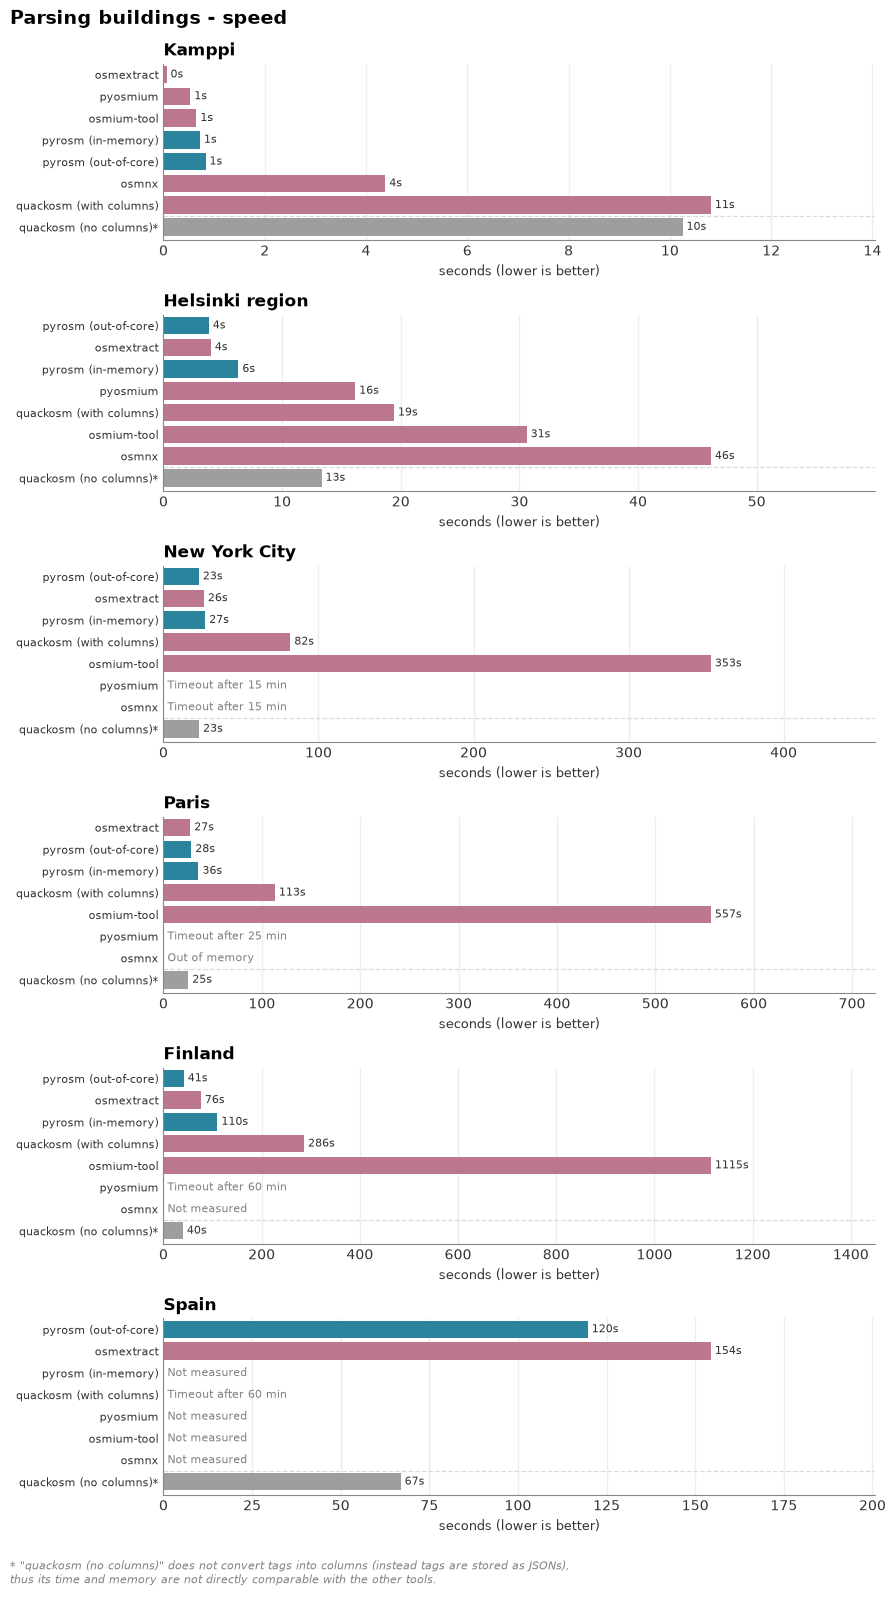

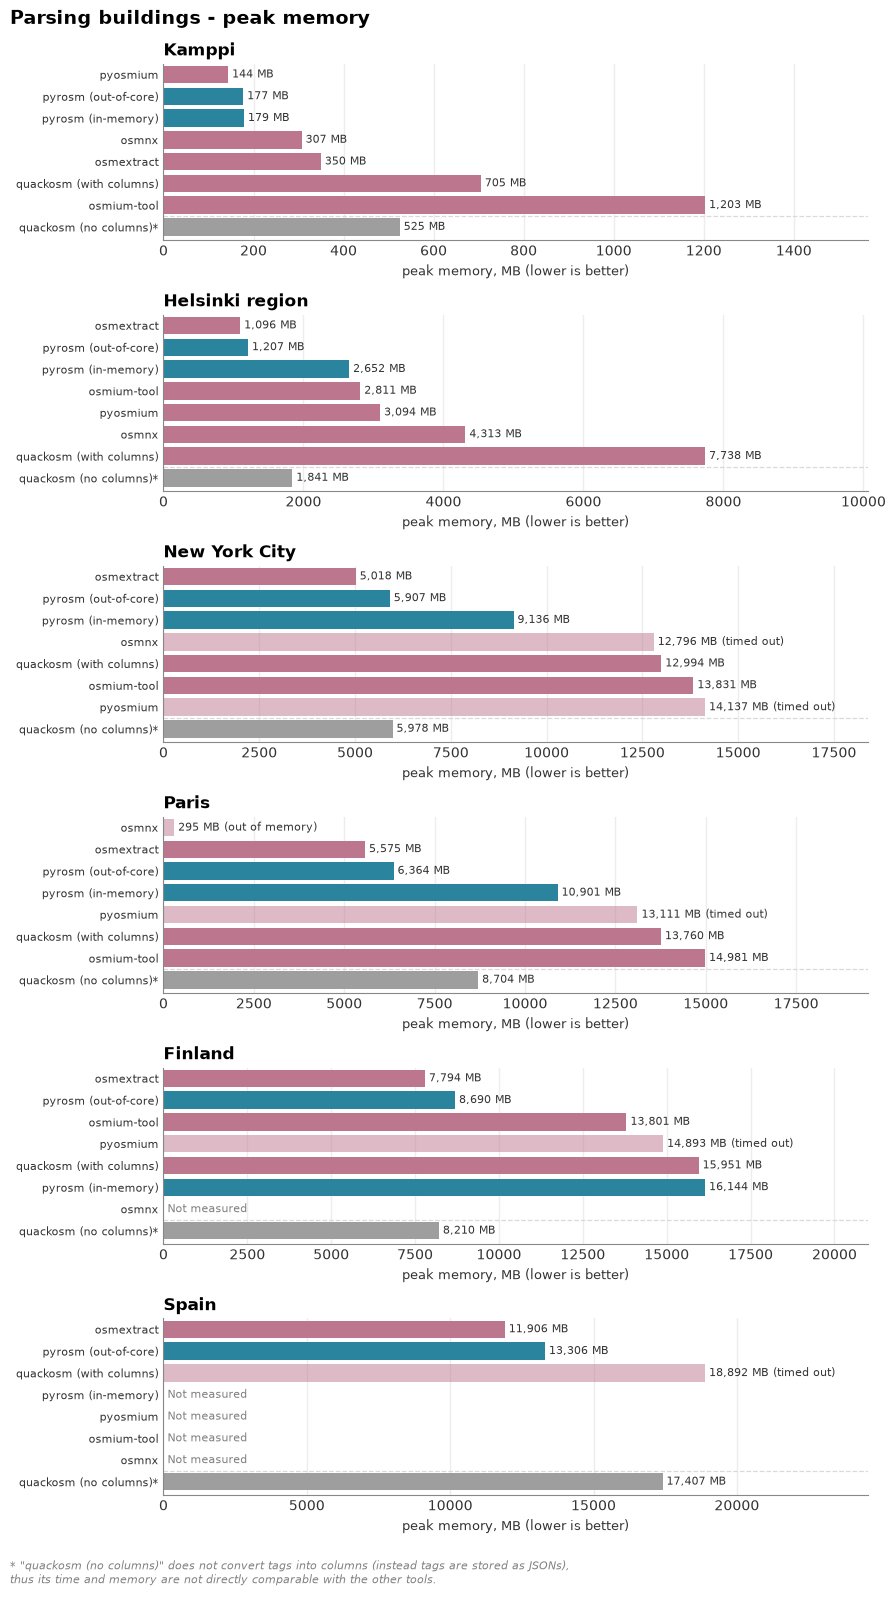

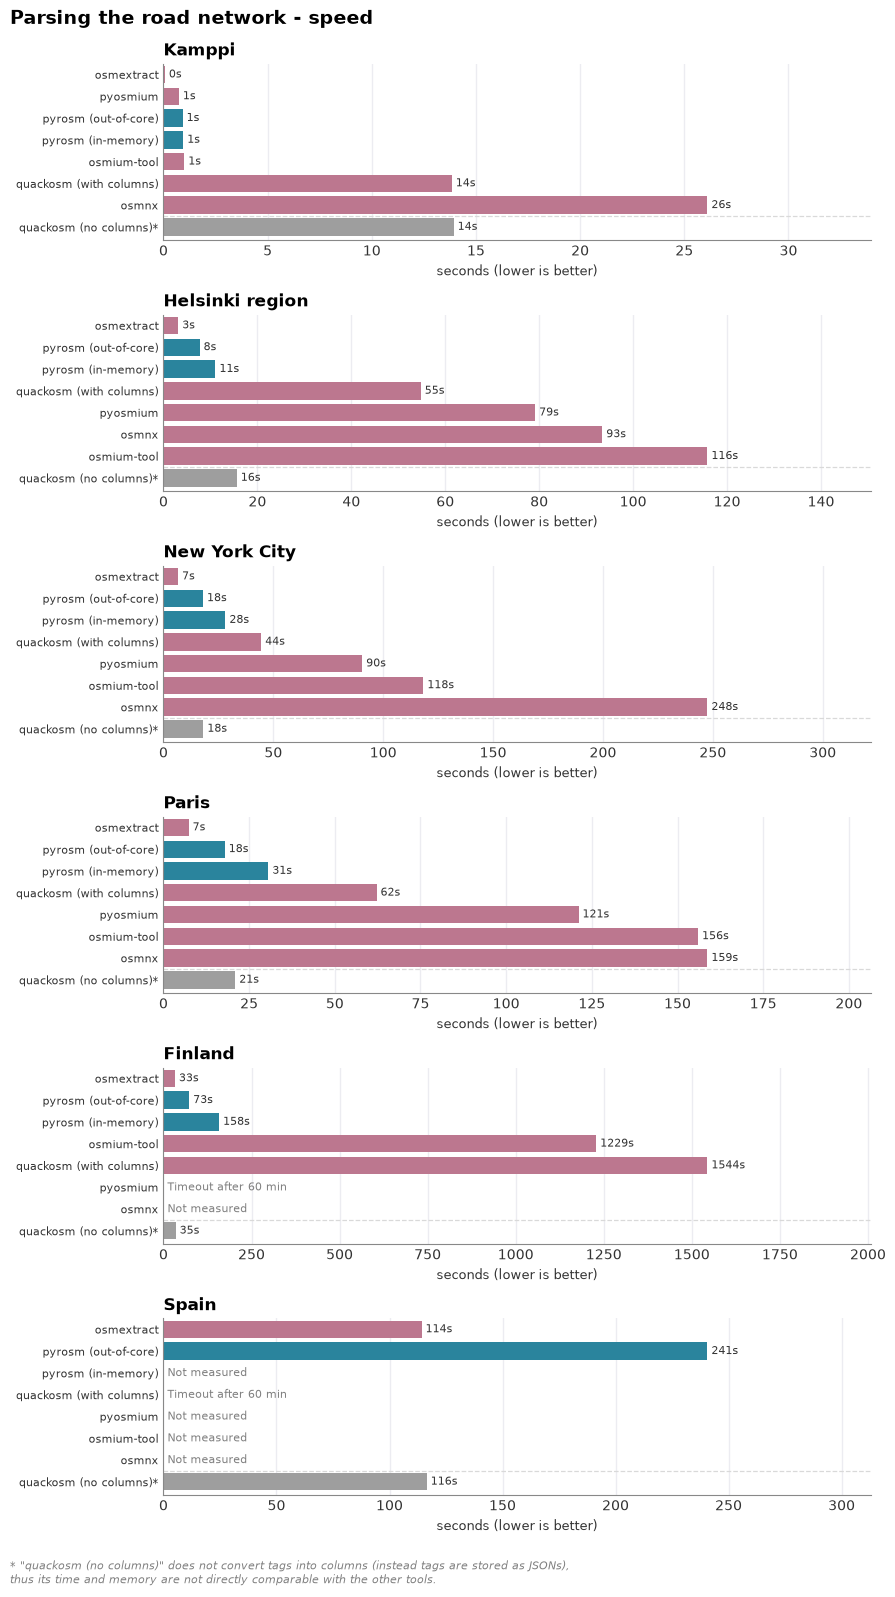

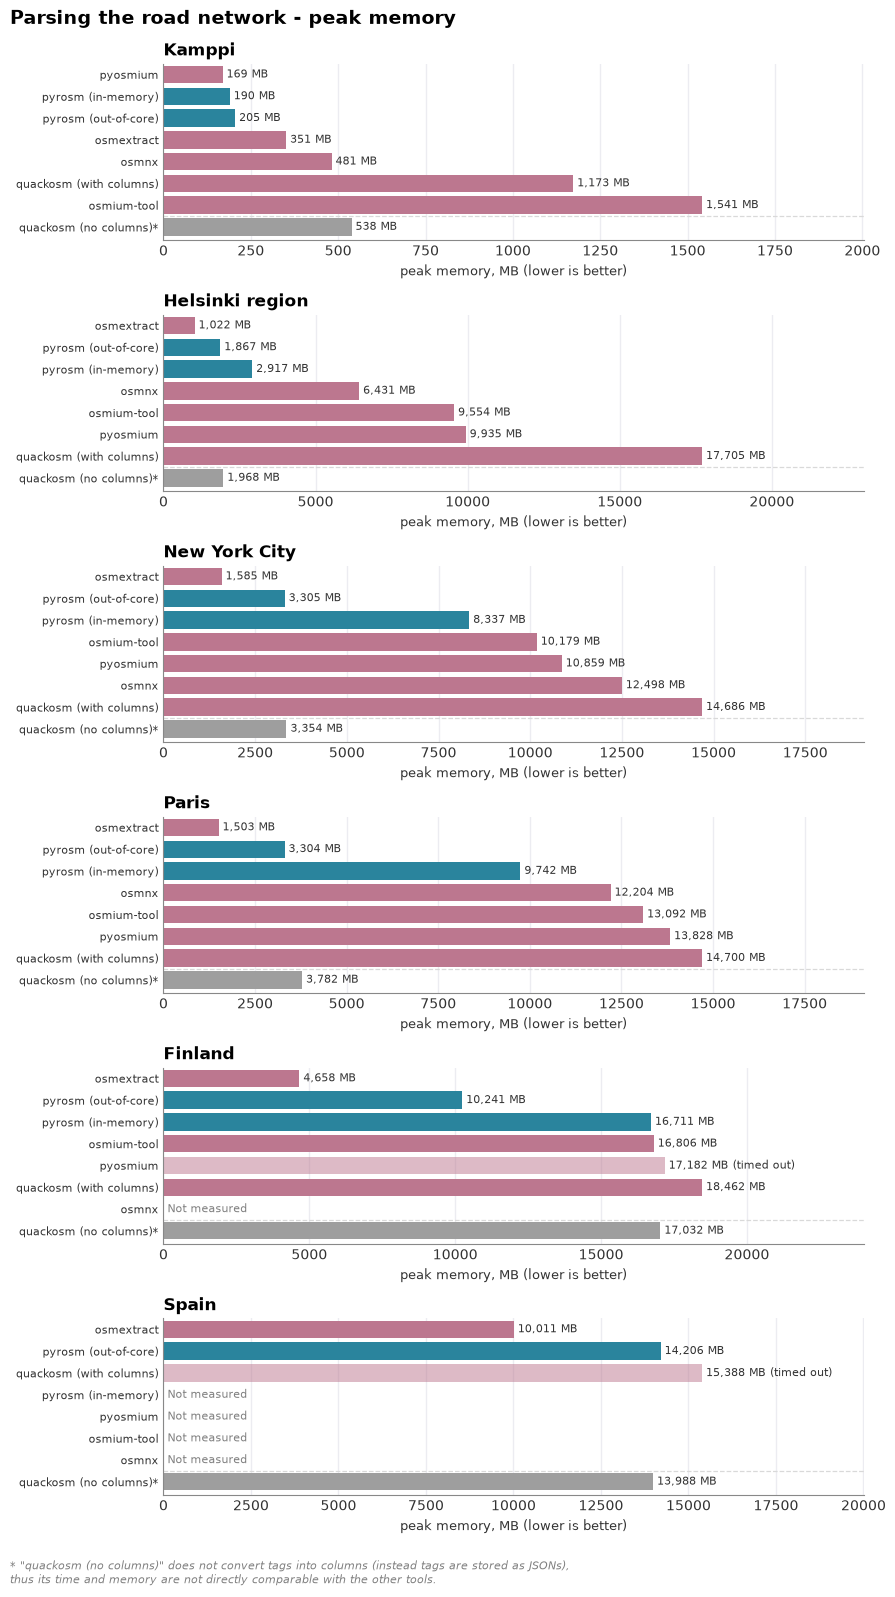

In [29]:
import math

# One figure per task and metric
# Ensure that the AREAS include every area
AREAS = [
    Area("Kamppi",          KAMPPI_PBF,        10,  120),
    Area("Helsinki region", REGION_PBF,        10,  300),
    Area("New York City",   NEW_YORK_PBF,       5,  900),
    Area("Paris",           PARIS_PBF,          3, 1500),
    Area("Finland",         FINLAND_PBF,        3, 3600),
    Area("Spain",           SPAIN_PBF,          3, 3600),
    Area("South America",   SOUTH_AMERICA_PBF,  1, 3600),
]

area_order = [a.label for a in AREAS]
AREA_TIMEOUT = {a.label: a.timeout for a in AREAS}
TOOL_ORDER = ["pyrosm (in-memory)", "pyrosm (out-of-core)", "quackosm (with columns)", "quackosm (no columns)", "pyosmium",
              "osmium-tool", "osmnx", "osmextract"]
SPECIAL_TOOL = "quackosm (no columns)"   # not comparable: tags kept as JSON, not exploded to columns
SPECIAL_COLOR = "#9E9E9E"
SPECIAL_NOTE = ('* "quackosm (no columns)" does not convert tags into columns (instead tags are stored as JSONs), \n'
                "thus its time and memory are not directly comparable with the other tools.")


def _status_note(row, area):
    """Why a tool has no value for this metric, written where its bar would be."""
    if row is None:
        return "Not measured"
    status = str(row["status"])
    if status == "timeout":
        return f"Timeout after {int(round(AREA_TIMEOUT.get(area, 0) / 60))} min"
    if "OOM" in status:
        return "Out of memory"
    return "Not measured"


def _incomplete_tag(row):
    """Suffix marking a value whose run did not finish, so a peak-memory bar for a timed-out
    or killed run is shown but not read as a completed measurement."""
    status = "ok" if row is None else str(row["status"])
    if status == "timeout":
        return " (timed out)"
    if "OOM" in status:
        return " (out of memory)"
    return ""


def plot_per_area(task, metric, xlabel, fmt, suptitle, png):
    table = (parsing_table[parsing_table["task"] == task]
             .drop_duplicates(subset=["area", "tool"], keep="last"))
    areas = [a for a in area_order if a in set(table["area"])]
    if not areas:
        print(f"No rows for task={task!r} yet.")
        return

    fig, axes = plt.subplots(len(areas), 1, figsize=(9, 2.7 * len(areas)), squeeze=False)
    for ax, area in zip(axes[:, 0], areas):
        sub = table[table["area"] == area].set_index("tool")
        entries = []
        for tool in TOOL_ORDER:
            row = sub.loc[tool] if tool in sub.index else None
            if row is not None and pd.notna(row[metric]):
                # A captured value is a bar -- including an incomplete run (timeout / OOM) whose
                # peak memory was still sampled; it is faded and its label tagged below.
                entries.append((tool, float(row[metric]), None, _incomplete_tag(row)))
            else:
                # No value for this metric -> a grey note explains why.
                entries.append((tool, math.nan, _status_note(row, area), ""))

        # Sort the comparable tools by value; pin the not-comparable "no columns" variant to the bottom.
        special = [e for e in entries if e[0] == SPECIAL_TOOL]
        normal = [e for e in entries if e[0] != SPECIAL_TOOL]
        normal.sort(key=lambda e: e[1] if e[2] is None else math.inf)
        entries = normal + special

        n = len(entries)
        for i, (tool, value, note, tag) in enumerate(entries):
            y = n - 1 - i                          # fastest / lowest at the top
            if note is None:
                if tool == SPECIAL_TOOL:
                    color = SPECIAL_COLOR
                elif tool.startswith("pyrosm"):
                    color = PYROSM_COLOR
                else:
                    color = OTHER_COLOR
                ax.barh(y, value, color=color, alpha=1.0 if tag == "" else 0.5)
                ax.text(value, y, " " + fmt(value) + tag, va="center", ha="left",
                        fontsize=8, color="#333333")
            else:
                ax.text(0, y, " " + note, va="center", ha="left", fontsize=8, color="grey")
        if special:                                # set the not-comparable row off from the rest
            ax.axhline(0.5, color="#d9d9d9", lw=0.9, ls="--")
        ax.set_yticks([n - 1 - i for i in range(n)])
        ax.set_yticklabels([e[0] + ("*" if e[0] == SPECIAL_TOOL else "") for e in entries], fontsize=8)
        ax.set_ylim(-0.6, n - 0.5)                 # space below the last row so its note clears the x-axis
        ax.set_title(area, loc="left", fontsize=12, fontweight="bold")
        ax.set_xlabel(xlabel, fontsize=9)
        ax.grid(axis="y", visible=False)
        ax.tick_params(length=0)
        measured = [e[1] for e in entries if e[1] == e[1]]
        ax.set_xlim(0, (max(measured) if measured else 1) * 1.3)   # headroom for value labels + tags

    fig.suptitle(suptitle, fontsize=14, fontweight="bold", x=0.01, ha="left")
    bottom = 0.0
    if SPECIAL_TOOL in TOOL_ORDER:
        fig.text(0.01, 0.006, SPECIAL_NOTE, ha="left", va="bottom",
                 fontsize=8, color="grey", style="italic")
        bottom = 0.03
    fig.tight_layout(rect=[0, bottom, 1, 0.99])
    fig.savefig(f"{FIGURE_DIR}/{png}")
    plt.show()


plot_per_area("buildings", "seconds", "seconds (lower is better)", lambda v: f"{v:.0f}s",
              "Parsing buildings - speed", "buildings_time.png")
plot_per_area("buildings", "peak_mb", "peak memory, MB (lower is better)", lambda v: f"{v:,.0f} MB",
              "Parsing buildings - peak memory", "buildings_memory.png")
plot_per_area("roads", "seconds", "seconds (lower is better)", lambda v: f"{v:.0f}s",
              "Parsing the road network - speed", "network_time.png")
plot_per_area("roads", "peak_mb", "peak memory, MB (lower is better)", lambda v: f"{v:,.0f} MB",
              "Parsing the road network - peak memory", "network_memory.png")


### Reading buildings with identical workload — pyrosm vs quackosm

Time and peak memory side by side, one area per row. Each panel keeps its own scale, so the small areas stay readable next to the big ones — lower is better for both.

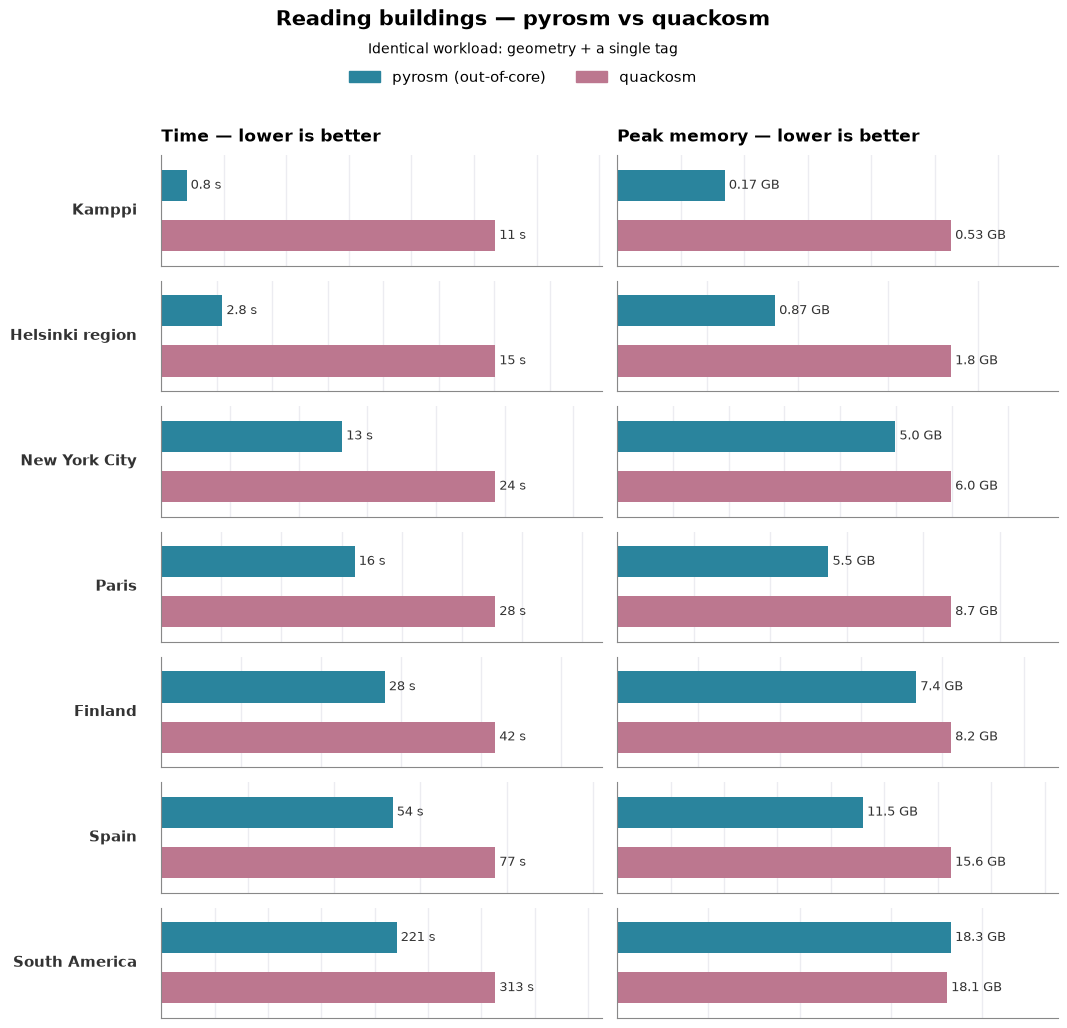

In [30]:
# Head-to-head: pyrosm (out-of-core) vs quackosm reading buildings, time and peak memory side by
# side, one row per area. Each panel keeps its own x-scale so the small areas are not dwarfed by
# the big ones (lower is better for both).
H2H_TASK = "buildings (geometry + key)"
PYROSM_H2H, QUACK_H2H = "pyrosm (out-of-core)", "quackosm"

h2h = (parsing_table[parsing_table["task"] == H2H_TASK]
       .drop_duplicates(subset=["area", "tool"], keep="last"))
h2h_areas = [a for a in area_order if a in set(h2h["area"])]


def _secs(v):
    return f"{v:.0f} s" if v >= 10 else f"{v:.1f} s"


def _gb(v):
    return f"{v/1000:.1f} GB" if v >= 1000 else f"{v/1000:.2f} GB"


METRICS = [("seconds", "Time — lower is better", _secs),
           ("peak_mb", "Peak memory — lower is better", _gb)]

fig, axes = plt.subplots(len(h2h_areas), 2, figsize=(11, 1.5 * len(h2h_areas)), squeeze=False)
for r, area in enumerate(h2h_areas):
    sub = h2h[h2h["area"] == area].set_index("tool")
    for c, (metric, header, fmt) in enumerate(METRICS):
        ax = axes[r, c]
        pv, qv = float(sub.loc[PYROSM_H2H, metric]), float(sub.loc[QUACK_H2H, metric])
        ax.barh([1, 0], [pv, qv], color=[PYROSM_COLOR, OTHER_COLOR], height=0.62)
        for y, v in ((1, pv), (0, qv)):
            ax.text(v, y, " " + fmt(v), va="center", ha="left", fontsize=9, color="#333333")
        ax.set_xlim(0, max(pv, qv) * 1.32)
        ax.set_ylim(-0.6, 1.6)
        ax.set_yticks([1, 0])
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        ax.grid(axis="y", visible=False)
        ax.tick_params(length=0)
        if r == 0:
            ax.set_title(header, loc="left", fontsize=12, fontweight="bold", pad=10)
    axes[r, 0].set_ylabel(area, rotation=0, ha="right", va="center", fontsize=11,
                          fontweight="bold", labelpad=14)

handles = [plt.Rectangle((0, 0), 1, 1, color=PYROSM_COLOR),
           plt.Rectangle((0, 0), 1, 1, color=OTHER_COLOR)]
fig.suptitle("Reading buildings — pyrosm vs quackosm", fontsize=15, fontweight="bold",
             x=0.5, ha="center", y=0.995)
fig.text(s="Identical workload: geometry + a single tag", fontsize=10, #fontweight="bold",
             x=0.5, ha="center", y=0.953)
fig.legend(handles, ["pyrosm (out-of-core)", "quackosm"], loc="upper center",
           bbox_to_anchor=(0.5, 0.95), ncol=2, frameon=False, fontsize=11)
fig.tight_layout(rect=[0.02, 0.02, 1, 0.93])
fig.savefig(f"{FIGURE_DIR}/head_to_head.png")
plt.show()


### Time to crop a country-level PBF into a smaller one

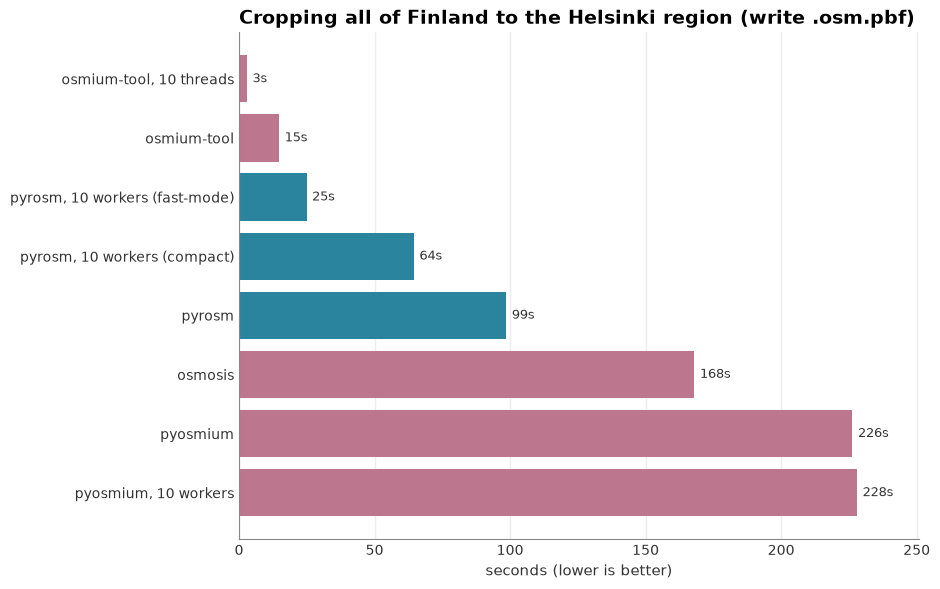

In [31]:
# Crop times: horizontal bars, fastest at the top, with pyrosm highlighted.
if "crop_table" in globals() and not crop_table.empty:
    runs = crop_table[crop_table["status"] == "ok"].copy()
    # The serial (single-process) crop rows carry no parallelism label ("run"); show them
    # under the tool name. Without this the "run" column is a float (NaN) for those rows and
    # the categorical y-axis raises "TypeError: 'value' must be ... not a float".
    if "run" not in runs.columns:
        runs["run"] = runs["tool"]
    else:
        runs["run"] = runs["run"].fillna(runs["tool"])
    runs = runs.sort_values("seconds")

    fig, ax = plt.subplots(figsize=(9.5, 6))
    bars = ax.barh(runs["run"], runs["seconds"], color=bar_colors(runs["tool"]))
    ax.bar_label(bars, fmt="%.0fs", padding=4, fontsize=9.5, color="#333333")
    ax.invert_yaxis()   # fastest at the top
    ax.set_xlim(0, runs["seconds"].max() * 1.10)   # headroom for the bar labels
    ax.grid(axis="y", visible=False)
    ax.tick_params(length=0)
    ax.set_xlabel("seconds (lower is better)")
    ax.set_title("Cropping all of Finland to the Helsinki region (write .osm.pbf)",
                 loc="left", fontsize=14)

    fig.tight_layout()
    fig.savefig(f"{FIGURE_DIR}/crop_times.png")
    plt.show()
